# Real Data Reconstruction

Converts `aligned_center_points.mat` (x, y pixel coordinates from video) into a
`cosserat_simulation_data_Verlet.mat`-compatible format with all 6 state groups:

| Group | Symbol | Size | Description |
|-------|--------|------|-------------|
| 1 | x | N+1 | Horizontal position (m) |
| 2 | y | N+1 | Vertical position (m) |
| 3 | θ | N | Segment tangent angle (rad) |
| 4 | p_x | N+1 | Linear momentum x = ρA · ẋ |
| 5 | p_y | N+1 | Linear momentum y = ρA · ẏ |
| 6 | p_θ | N | Angular momentum = ρI · θ̇ |

**Pipeline:**
1. Load raw pixel data
2. Pixel-to-meter calibration
3. Downsample 100 → N+1 nodes to match simulation
4. Compute θ geometrically from (x, y)
5. Smooth all states temporally (Savitzky-Golay)
6. Compute time derivatives (ẋ, ẏ, θ̇) by finite difference on smoothed data
7. Compute conjugate momenta (p_x, p_y, p_θ)
8. Enforce boundary conditions (clamped base)
9. Sanity checks and visualisation
10. Save as `.mat`

In [115]:
# !pip install scipy
# !pip install matplotlib
# !pip install numpy

In [119]:
# ── Data file inspection (run before anything else) ──────────────────────
import numpy as np, os

_txt = "centerline_data_25pts.txt"
data = np.loadtxt(_txt)
# _txt = "centerline_data_LATEST.txt" # updated on 2024-06-17
assert os.path.exists(_txt), f"File not found: {_txt}"
_data = np.loadtxt(_txt)
n_rows, n_cols = _data.shape

# Detect format: last col is timestamp (large Unix time > 1e9), second-last is frame index
_has_timestamp = _data[-1, -1] > 1e9
_has_frame_idx = not _has_timestamp or True # always present

if _has_timestamp:
    _ts = _data[:, -1]
    _frame_idx = _data[:, -2].astype(int)
    _n_xy_cols = n_cols - 2
else:
    _ts = None
    _frame_idx = _data[:, -1].astype(int)
    _n_xy_cols = n_cols - 1

_n_pts = _n_xy_cols // 2 # x0..xN-1, y0..yN-1

print("=" * 50)
print(" centerline_data.txt — inspection")
print("=" * 50)
print(f" Frames (rows) : {n_rows}")
print(f" Columns : {n_cols}")
print(f" Points per frame : {_n_pts} (N_VIDEO_PTS)")
print(f" Has timestamps : {_has_timestamp}")

if _has_timestamp:
    _dt = np.diff(_ts)
    _fps_mean = 1.0 / _dt.mean()
    _fps_median = 1.0 / np.median(_dt)
    _duration = _ts[-1] - _ts[0]
    print(f" Duration : {_duration:.3f} s")
    print(f" FPS (mean) : {_fps_mean:.2f} Hz")
    print(f" FPS (median) : {_fps_median:.2f} Hz ← use this in Cell 3")
    print(f" dt mean/std : {_dt.mean()*1000:.2f} ms / {_dt.std()*1000:.2f} ms")
    print(f" dt min/max : {_dt.min()*1000:.2f} ms / {_dt.max()*1000:.2f} ms")
else:
    print(f" No timestamps — FPS must be set manually in Cell 3")

print(f" Frame index : {_frame_idx[0]} → {_frame_idx[-1]}")
print("=" * 50)
print(f" → Set in Cell 3: N_VIDEO_PTS = {_n_pts}")
if _has_timestamp:
    print(f" → Set in Cell 3: FPS = {_fps_median:.2f}")
print("=" * 50)




 centerline_data.txt — inspection
 Frames (rows) : 414
 Columns : 52
 Points per frame : 25 (N_VIDEO_PTS)
 Has timestamps : True
 Duration : 6.013 s
 FPS (mean) : 68.68 Hz
 FPS (median) : 64.98 Hz ← use this in Cell 3
 dt mean/std : 14.56 ms / 3.26 ms
 dt min/max : 9.79 ms / 41.13 ms
 Frame index : 0 → 413
 → Set in Cell 3: N_VIDEO_PTS = 25
 → Set in Cell 3: FPS = 64.98


In [120]:
import numpy as np
data = np.loadtxt(_txt) # data = np.loadtxt('centerline_data_25pts.txt')
# data = np.loadtxt('centerline_data_LATEST.txt') # updated on 2024-06-17
x_px = data[:, :25]
y_px = data[:, 25:50]

# Compute pixel arc length per frame
arc_px = np.sqrt(np.diff(x_px, axis=1)**2 + np.diff(y_px, axis=1)**2).sum(axis=1)

# Find most vertical frame (smallest arc) and most extreme frame (largest arc)
frame_min = np.argmin(arc_px)   # shortest measured arc = most vertical
frame_max = np.argmax(arc_px)   # longest measured arc = most extreme

print(f'Shortest arc: frame {frame_min}, arc={arc_px[frame_min]:.1f} px')
print(f'  x range: [{x_px[frame_min].min():.0f}, {x_px[frame_min].max():.0f}] px')
print(f'  y range: [{y_px[frame_min].min():.0f}, {y_px[frame_min].max():.0f}] px')
print()
print(f'Longest arc:  frame {frame_max}, arc={arc_px[frame_max]:.1f} px')
print(f'  x range: [{x_px[frame_max].min():.0f}, {x_px[frame_max].max():.0f}] px')
print(f'  y range: [{y_px[frame_max].min():.0f}, {y_px[frame_max].max():.0f}] px')

# Check spacing uniformity
spacing_min = np.sqrt(np.diff(x_px[frame_min])**2 + np.diff(y_px[frame_min])**2)
spacing_max = np.sqrt(np.diff(x_px[frame_max])**2 + np.diff(y_px[frame_max])**2)
print(f'\nPixel spacing (vertical frame):  mean={spacing_min.mean():.1f}  std={spacing_min.std():.1f} px')
print(f'Pixel spacing (extreme frame):   mean={spacing_max.mean():.1f}  std={spacing_max.std():.1f} px')


Shortest arc: frame 160, arc=249.4 px
  x range: [168, 309] px
  y range: [0, 204] px

Longest arc:  frame 325, arc=310.0 px
  x range: [309, 548] px
  y range: [0, 194] px

Pixel spacing (vertical frame):  mean=10.4  std=0.5 px
Pixel spacing (extreme frame):   mean=12.9  std=0.8 px


## Step 1 — Configuration

Set all physical parameters and calibration constants here.
Everything downstream reads from this cell.

In [130]:
import numpy as np
import scipy.io as sio
from scipy.signal import savgol_filter
from scipy.interpolate import interp1d
import matplotlib.pyplot as plt

# ── Figure defaults ──────────────────────────────────────────────────────────
import matplotlib
matplotlib.rcParams['figure.dpi']     = 100
matplotlib.rcParams['figure.figsize'] = (8, 4)
import os

# ── Paths ──────────────────────────────────────────────────────────────────
# INPUT_MAT   = '../Data/Real_data/aligned_center_points_live.mat'
# INPUT_MAT   = '../aligned_center_points_live.mat'
# INPUT_MAT   = '../Data/Real_data/centerline_data.mat'
# INPUT_MAT   = '../Data/Real_data/centerline_data_new.mat'
# INPUT_MAT   = '../Data/Real_data/centerline_data_m.mat'
# INPUT_TXT   = '../Data/Real_data/centerline_data_new.txt'  # read .txt directly
INPUT_TXT   = 'centerline_data_25pts.txt'  # read .txt directly

# OUTPUT_MAT      = 'cosserat_real_data.mat'
# OUTPUT_MAT_DOT  = 'cosserat_real_data_dot.mat'
OUTPUT_MAT      = '../../../Data/Real_data/cosserat_real_data.mat'
OUTPUT_MAT_DOT  = '../../../Data/Real_data/cosserat_real_data_dot.mat'

# ── Rod discretisation ─────────────────────────────────────────────────────
N   = 25          # number of segments  → N+1 = 26 nodes
L0  = 0.515       # real rod physical length (m) — measured directly

# ── Physical parameters ────────────────────────────────────────────────────
rho   = 1000.0                    # density (kg/m³)
d     = 3e-3                       # cross-section display (m)
# a     = 0.02                      # cross-section width (m) — for square rod
A     = np.pi * d**2 / 4          # cross-sectional area (m²)
# A     = a**2              # cross-sectional area (m²) — corrected for square rod
I     = A**2 / (4 * np.pi)        # second moment of area (m⁴)
# I     = a**2 / 12                   # second moment of area (m⁴) — corrected for square rod
# E     = 3e6                       # Young's modulus (Pa)
# G     = E / (2 * (1 + 0.5))       # shear modulus (Pa)

# ── Video / calibration ────────────────────────────────────────────────────
FPS           = 64.98   # camera frame rate (Hz)
# N_VIDEO_PTS is auto-detected from the .txt file in the load cell
# (100 for old ros_centerline.py data, 25 for ros_centerline_2.py data)

# Pixel-to-metre scale factor.
# Node 0 is the clamp (zero variance); node ordering is clamp→tip.
# Median arc length across all frames = 374.5 px; L0 = 0.3 m → 1248.2 px/m
PIXELS_PER_METRE = None # set to None to auto-calibrate in Step 3 (recommended)

# Clamp pixel position — node 0 of the raw data (fixed point, zero variance).
CLAMP_PX = np.array([309.0, 0.0])  # [x_px, y_px]

# ── Frame trimming ─────────────────────────────────────────────────────────
# Frames to drop from the START of the recording (initial transient).
# At FPS=194:  60 frames ≈ 0.31 s,  120 frames ≈ 0.62 s.  Set 0 to keep all.
TRIM_FRAMES = 0

# ── Coordinate orientation ─────────────────────────────────────────────────
ROTATE_TO_HORIZONTAL = False

# ── Smoothing (legacy — kept for reference, superseded by GP) ──────────────
SG_WINDOW  = 11    # Savitzky-Golay window (frames, must be odd > SG_POLY)
SG_POLY    = 3     # polynomial order

# ── GP configuration ───────────────────────────────────────────────────────
# N_TRAIN_PTS : how many spatial points (columns) to train GPs on.
#               Set to N_VIDEO_PTS to use all raw video points.
#               Assigned in the load cell once N_VIDEO_PTS is known.
# N_TRAIN_PTS is set in the load cell — do not hardcode here.

# GP_STRIDE   : use every GP_STRIDE-th frame for GP training (speeds up fitgp).
#               1 = use all frames; increase if training is too slow.
GP_STRIDE   = 2

# N_DENSE     : number of spatial query points used to compute θ accurately.
#               Dense query → smooth tangent angle; subsample to N segments.
N_DENSE     = 500

print('Configuration loaded.')
print(f'  N = {N}  (nodes = {N+1})')
print(f'  L0 = {L0} m  (real rod physical length)')
print(f'  rho = {rho}  A = {A:.4e}  I = {I:.4e}')
print(f'  FPS = {FPS}  dt = {1/FPS*1000:.3f} ms')
if PIXELS_PER_METRE is not None:
    print(f'  PIXELS_PER_METRE = {PIXELS_PER_METRE}  ({1/PIXELS_PER_METRE*1000:.3f} mm/px)')
else:
    print(f'  PIXELS_PER_METRE = None  (will auto-calibrate in Step 3)')
print(f'  CLAMP_PX = {CLAMP_PX}')
print(f'  TRIM_FRAMES = {TRIM_FRAMES}  ({TRIM_FRAMES/FPS*1000:.0f} ms trimmed from start)')
print(f'  ROTATE_TO_HORIZONTAL = {ROTATE_TO_HORIZONTAL}')
print(f'  N_VIDEO_PTS and N_TRAIN_PTS will be set in the load cell.')
print(f'  GP: GP_STRIDE={GP_STRIDE}, N_DENSE={N_DENSE}')


Configuration loaded.
  N = 25  (nodes = 26)
  L0 = 0.515 m  (real rod physical length)
  rho = 1000.0  A = 7.0686e-06  I = 3.9761e-12
  FPS = 64.98  dt = 15.389 ms
  PIXELS_PER_METRE = None  (will auto-calibrate in Step 3)
  CLAMP_PX = [309.   0.]
  TRIM_FRAMES = 0  (0 ms trimmed from start)
  ROTATE_TO_HORIZONTAL = False
  N_VIDEO_PTS and N_TRAIN_PTS will be set in the load cell.
  GP: GP_STRIDE=2, N_DENSE=500


## Step 1b — Live Data Calibration

Run this cell **once** after recording a new session with `live_centerline.py`.
It reads your `.mat` file and prints the exact values to paste into the config above.

**Checks performed:**
1. `PIXELS_PER_METRE` — computed from median pixel arc-length vs. real rod length `L0`
2. `CLAMP_PX` — read from point 0 of frame 0 (always the pinned clamp point)
3. Arc-length outliers — frames where arc-length deviates >20% from median (collapsed skeleton)
4. Tip-jump outliers — frames where the tip moves >15 px from the previous frame (tracking glitch)
5. Summary plot — raw x(t) and y(t) at 4 nodes so you can visually confirm data quality

Loaded 414 frames × 25 pts from centerline_data_25pts.txt
Frame index range: 0 → 413

--- Calibration values (paste into cell-01-config) ---
PIXELS_PER_METRE = 588.7   (median arc = 303.2 px, L0 = 0.515 m → 1.699 mm/px)
CLAMP_PX = np.array([309.0, 0.0])  (node 0, std=0.00 px)

--- Data quality ---
Arc-length outliers (>50% from median): 0 / 414 frames
Tip-jump outliers (>500 px/frame, node 24): 0 / 414 frames
t =  s (total duration: 6.36 s)


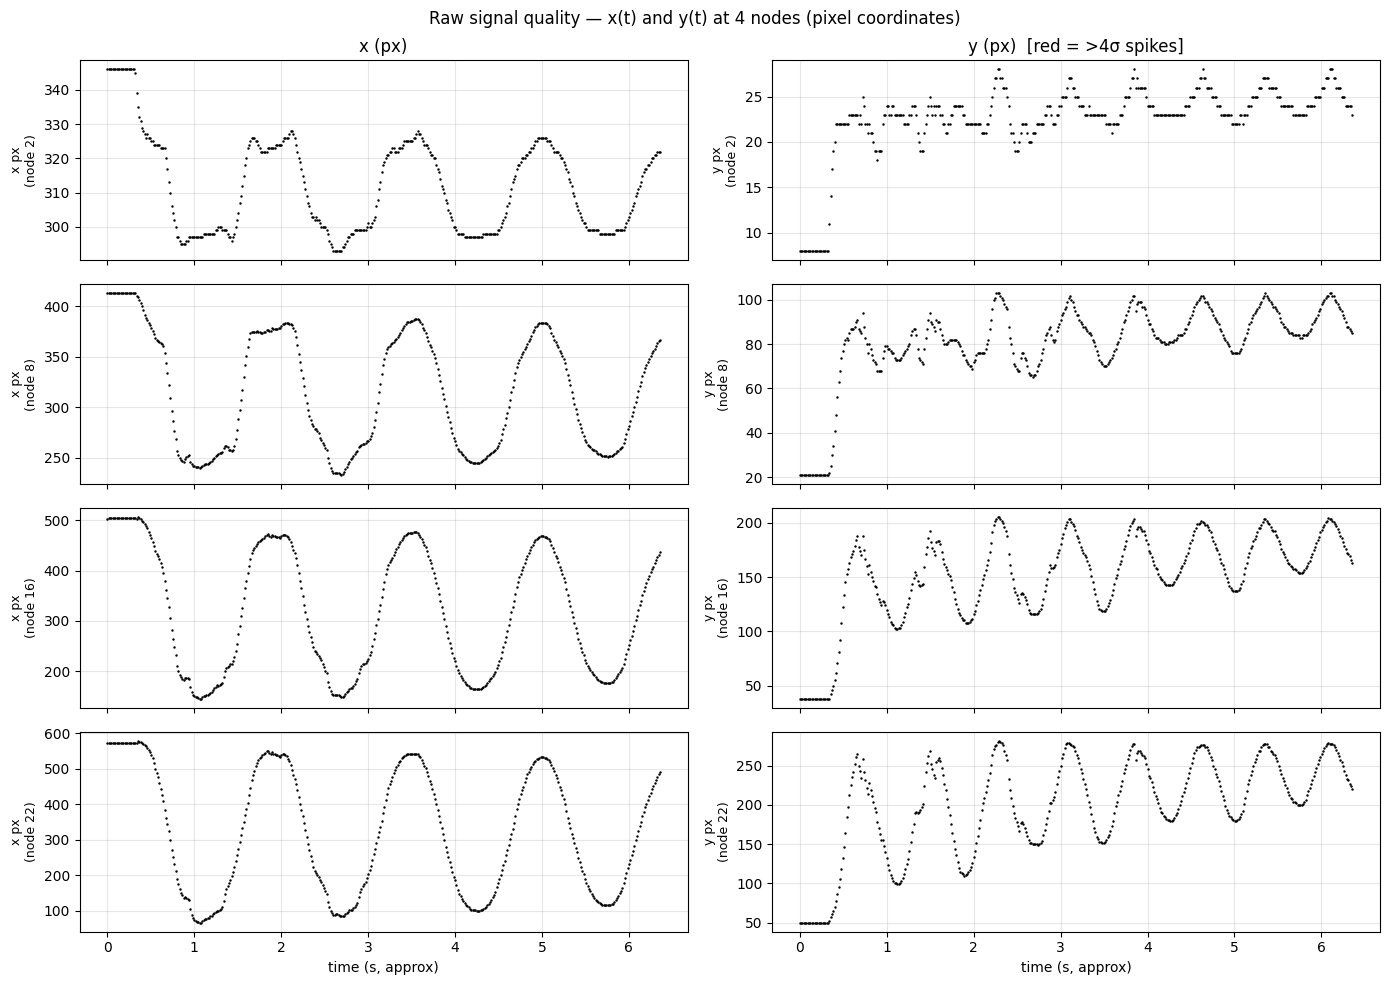


Copy the PIXELS_PER_METRE and CLAMP_PX lines above into cell-01-config, then re-run the notebook.


In [131]:
# ── Live data calibration ─────────────────────────────────────────────────
# Run this cell after recording a new session to get the values to paste
# into the config cell above (cell-01-config).
# Requires: INPUT_TXT, L0  (from cell-01-config)
# N_VIDEO_PTS is auto-detected from the file
# ──────────────────────────────────────────────────────────────────────────

import numpy as np
import scipy.io as sio
import matplotlib.pyplot as plt

# _raw = sio.loadmat(INPUT_MAT)
_data_txt   = np.loadtxt(INPUT_TXT)
_n_frames   = _data_txt.shape[0]
N_VIDEO_PTS = (_data_txt.shape[1] - 1) // 2  # auto-detect: 100 (old) or 25 (ros_centerline_2)
_x_px  = _data_txt[:, :N_VIDEO_PTS].astype(float)
_y_px  = _data_txt[:, N_VIDEO_PTS:2*N_VIDEO_PTS].astype(float)
_z_idx = _data_txt[:, 2*N_VIDEO_PTS].astype(float)
# _x_flat = _raw['x'].ravel().astype(float)
# _y_flat = _raw['y'].ravel().astype(float)
# _z_flat = _raw['z'].ravel().astype(float)

# _n_total  = len(_x_flat)
# _n_frames = _n_total // N_VIDEO_PTS
# assert _n_total % N_VIDEO_PTS == 0, \
#     f'Total points {_n_total} not divisible by N_VIDEO_PTS={N_VIDEO_PTS}'

# _x_px = _x_flat.reshape(_n_frames, N_VIDEO_PTS)
# _y_px = _y_flat.reshape(_n_frames, N_VIDEO_PTS)
# _z_idx = _z_flat.reshape(_n_frames, N_VIDEO_PTS)[:, 0]

print(f'Loaded {_n_frames} frames × {N_VIDEO_PTS} pts from {INPUT_TXT}')
print(f'Frame index range: {int(_z_idx.min())} → {int(_z_idx.max())}')

# ── 1. PIXELS_PER_METRE ──────────────────────────────────────────────────
_ds  = np.sqrt(np.diff(_x_px, axis=1)**2 + np.diff(_y_px, axis=1)**2)
_arc = _ds.sum(axis=1)
_med_arc = float(np.median(_arc))
_ppm = _med_arc / L0

print(f'\n--- Calibration values (paste into cell-01-config) ---')
print(f'PIXELS_PER_METRE = {_ppm:.1f}   '
      f'(median arc = {_med_arc:.1f} px, L0 = {L0} m → {1/_ppm*1000:.3f} mm/px)')

# ── 2. CLAMP_PX — identify by minimum variance across frames ─────────────
_x_std = _x_px.std(axis=0)
_y_std = _y_px.std(axis=0)
_clamp_node = int(np.argmin(_x_std + _y_std))
_clamp_x = float(_x_px[0, _clamp_node])
_clamp_y = float(_y_px[0, _clamp_node])
print(f'CLAMP_PX = np.array([{_clamp_x:.1f}, {_clamp_y:.1f}])  '
      f'(node {_clamp_node}, std={(_x_std+_y_std)[_clamp_node]:.2f} px)')

# ── 3. Arc-length outlier frames (>20% from median) ──────────────────────
_arc_tol = 0.5
_arc_bad  = np.where(np.abs(_arc - _med_arc) / _med_arc > _arc_tol)[0]
print(f'\n--- Data quality ---')
print(f'Arc-length outliers (>{_arc_tol*100:.0f}% from median): '
      f'{len(_arc_bad)} / {_n_frames} frames'
      + (f'  → frames {_arc_bad[:10].tolist()}{"…" if len(_arc_bad)>10 else ""}' if len(_arc_bad) else ''))

# ── 4. Tip-jump outliers (node furthest from clamp = max variance) ────────
_tip_node = int(np.argmax(_x_std + _y_std))
_tip_x = _x_px[:, _tip_node]
_tip_y = _y_px[:, _tip_node]
_tip_jump = np.sqrt(np.diff(_tip_x)**2 + np.diff(_tip_y)**2)
_jump_thr = 500
_jump_bad = np.where(_tip_jump > _jump_thr)[0] + 1
print(f'Tip-jump outliers (>{_jump_thr:.0f} px/frame, node {_tip_node}): '
      f'{len(_jump_bad)} / {_n_frames} frames'
      + (f'  → frames {_jump_bad[:10].tolist()}{"…" if len(_jump_bad)>10 else ""}' if len(_jump_bad) else ''))

# ── 5. Summary plot — x(t) and y(t) at 4 nodes ──────────────────────────
_inspect = [int(N_VIDEO_PTS * f) for f in (0.1, 0.33, 0.66, 0.9)]  # auto-scale to N_VIDEO_PTS
_t = (_z_idx - _z_idx[0]) / FPS
# print t total duration
print(f't =  s (total duration: {_t[-1]:.2f} s)')

fig, axes = plt.subplots(4, 2, figsize=(14, 10), sharex=True, dpi=100)
fig.suptitle('Raw signal quality — x(t) and y(t) at 4 nodes (pixel coordinates)', fontsize=12)
for _row, _col in enumerate(_inspect):
    _xc = _x_px[:, _col]
    _yc = _y_px[:, _col]
    _mu, _sd = _yc.mean(), _yc.std()
    _spk = np.abs(_yc - _mu) > 4 * _sd

    ax = axes[_row, 0]
    ax.plot(_t, _xc, 'k.', ms=1.5)
    ax.set_ylabel(f'x px\n(node {_col})', fontsize=9)
    ax.grid(True, alpha=0.3)

    ax = axes[_row, 1]
    ax.plot(_t, _yc, 'k.', ms=1.5)
    if _spk.any():
        ax.plot(_t[_spk], _yc[_spk], 'r.', ms=5, label=f'{_spk.sum()} spikes')
        ax.legend(fontsize=8)
    ax.set_ylabel(f'y px\n(node {_col})', fontsize=9)
    ax.grid(True, alpha=0.3)

axes[0, 0].set_title('x (px)')
axes[0, 1].set_title('y (px)  [red = >4σ spikes]')
axes[-1, 0].set_xlabel('time (s, approx)')
axes[-1, 1].set_xlabel('time (s, approx)')
plt.tight_layout()
plt.show()

print('\nCopy the PIXELS_PER_METRE and CLAMP_PX lines above into cell-01-config, then re-run the notebook.')


## Step 2 — Load raw pixel data

The `.mat` file from `skeletonization.ipynb` contains three flat 1-D arrays:
- `x` — pixel column (horizontal), length = N_VIDEO_PTS × n_frames
- `y` — pixel row (vertical), length = N_VIDEO_PTS × n_frames
- `z` — frame index for each point

We reshape into `(n_frames, N_VIDEO_PTS)` arrays.

In [132]:
# ── Step 2: Load raw pixel data ──────────────────────────────────────────
# Each row in the .txt file: [x0..x(N-1), y0..y(N-1), frame_index]
# N_VIDEO_PTS is inferred from the column count: (n_cols - 1) // 2
# raw = sio.loadmat(INPUT_MAT)
# print('Keys in file:', [k for k in raw.keys() if not k.startswith('_')])
# x_flat = raw['x'].ravel().astype(float)
# y_flat = raw['y'].ravel().astype(float)
# z_flat = raw['z'].ravel().astype(float)   # frame indices
# n_total = len(x_flat)
# n_frames = n_total // N_VIDEO_PTS

data_txt    = np.loadtxt(INPUT_TXT)             # (n_frames, 2*N_VIDEO_PTS + 1)
N_VIDEO_PTS = (data_txt.shape[1] - 1) // 2  # auto-detect: 100 (old) or 25 (ros_centerline_2)
N_TRAIN_PTS = N_VIDEO_PTS                    # train GPs on all available points
n_frames    = data_txt.shape[0]
x_px     = data_txt[:, :N_VIDEO_PTS].astype(float)           # (n_frames, N_VIDEO_PTS)
y_px     = data_txt[:, N_VIDEO_PTS:2*N_VIDEO_PTS].astype(float)
frame_indices = data_txt[:, 2*N_VIDEO_PTS].astype(float)     # (n_frames,)

# Trim initial transient frames
if TRIM_FRAMES > 0:
    x_px          = x_px[TRIM_FRAMES:]
    y_px          = y_px[TRIM_FRAMES:]
    frame_indices = frame_indices[TRIM_FRAMES:]
    n_frames      = len(frame_indices)
    print(f'Trimmed {TRIM_FRAMES} frames from start → {n_frames} frames remaining')

print(f'Loaded {n_frames} frames × {N_VIDEO_PTS} points  (N_TRAIN_PTS={N_TRAIN_PTS})')
print(f'Frame index range: {int(frame_indices.min())} → {int(frame_indices.max())}')
print(f'x range: [{x_px.min():.0f}, {x_px.max():.0f}] px')
print(f'y range: [{y_px.min():.0f}, {y_px.max():.0f}] px')


Loaded 414 frames × 25 points  (N_TRAIN_PTS=25)
Frame index range: 0 → 413
x range: [46, 598] px
y range: [0, 303] px


## Step 3 — Pixel-to-metre calibration & coordinate orientation

**Scale:** If `PIXELS_PER_METRE = None`, the scale is auto-derived from the
median pixel arc-length across all frames (assuming the rod is inextensible at L0).
The printed value tells you what to hard-code if you want to fix it.

**Origin:** Clamp pixel is shifted to (0, 0).

**y-axis:** Pixel rows increase downward; we flip so y increases upward.

**Orientation (optional):** The real rod is vertically clamped (hangs down).
If `ROTATE_TO_HORIZONTAL = True`, we apply a 90° clockwise rotation so the rod
extends rightward — matching the simulation's initial condition.

Auto-calibration:
  Median pixel arc length = 303.2 px
  → PIXELS_PER_METRE = 588.7  (hard-code this in config to fix it)

Clamp point max deviation: x=0.0 mm, y=0.0 mm
Arc length: mean=0.507 m  std=0.020 m  (expected ~0.515 m)

Tip position range (node -1):
  x_tip: [-0.447, 0.491] m
  y_tip: [-0.515, -0.090] m


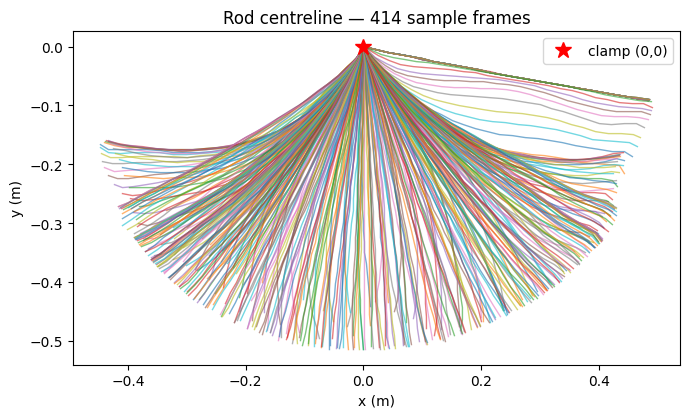


Arc length should be ≈ L0.  If not, check PIXELS_PER_METRE and CLAMP_PX.


In [133]:
# ── Step 3a: Auto-calibrate scale if needed ────────────────────────────────
if PIXELS_PER_METRE is None:
    ds_px = np.sqrt(np.diff(x_px, axis=1)**2 + np.diff(y_px, axis=1)**2)
    arc_px = ds_px.sum(axis=1)
    median_arc_px = np.median(arc_px)
    scale = median_arc_px / L0
    print(f'Auto-calibration:')
    print(f'  Median pixel arc length = {median_arc_px:.1f} px')
    print(f'  → PIXELS_PER_METRE = {scale:.1f}  (hard-code this in config to fix it)')
else:
    scale = PIXELS_PER_METRE
    print(f'Using fixed PIXELS_PER_METRE = {scale}')

# ── Step 3b: Convert to metres, origin at clamp (node 0) ──────────────────
# Node 0 is the clamp (confirmed by zero variance across all frames).
# Pixel convention: x = column (rightward), y = row (downward).
# Physical convention: x rightward, y upward  →  flip y.
x_m = ( x_px - CLAMP_PX[0]) / scale
y_m = -(y_px - CLAMP_PX[1]) / scale

# ── Step 3c: Optional 90° clockwise rotation ───────────────────────────────
if ROTATE_TO_HORIZONTAL:
    x_m_rot = -y_m.copy()
    y_m_rot =  x_m.copy()
    x_m, y_m = x_m_rot, y_m_rot
    print('90° rotation applied: rod now extends rightward from clamp.')

# ── Time vector ─────────────────────────────────────────────────────────────
t_raw = (frame_indices - frame_indices[0]) / FPS

# ── Diagnostics ─────────────────────────────────────────────────────────────
clamp_x_err = np.abs(x_m[:, 0]).max()
clamp_y_err = np.abs(y_m[:, 0]).max()
print(f'\nClamp point max deviation: x={clamp_x_err*1000:.1f} mm, y={clamp_y_err*1000:.1f} mm')

ds_approx = np.sqrt(np.diff(x_m, axis=1)**2 + np.diff(y_m, axis=1)**2)
arc_len = ds_approx.sum(axis=1)
print(f'Arc length: mean={arc_len.mean():.3f} m  std={arc_len.std():.3f} m  (expected ~{L0} m)')
print(f'\nTip position range (node -1):')
print(f'  x_tip: [{x_m[:,-1].min():.3f}, {x_m[:,-1].max():.3f}] m')
print(f'  y_tip: [{y_m[:,-1].min():.3f}, {y_m[:,-1].max():.3f}] m')

# ── Visualise ───────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 5), dpi=100)
for i in np.linspace(0, n_frames-1, n_frames, dtype=int):
    ax.plot(x_m[i], y_m[i], alpha=0.6, lw=1)
ax.plot(0, 0, 'r*', ms=12, label='clamp (0,0)')
ax.set_aspect('equal')
ax.set_xlabel('x (m)')
ax.set_ylabel('y (m)')
title = f'Rod centreline — {n_frames} sample frames'
if ROTATE_TO_HORIZONTAL:
    title += ' [rotated to horizontal]'
ax.set_title(title)
ax.legend()
plt.tight_layout()
plt.show()

print('\nArc length should be ≈ L0.  If not, check PIXELS_PER_METRE and CLAMP_PX.')


## Step 3b — Raw data inspection before GP training

Plot x(t) and y(t) at four nodes along the rod to understand the signal before any smoothing.

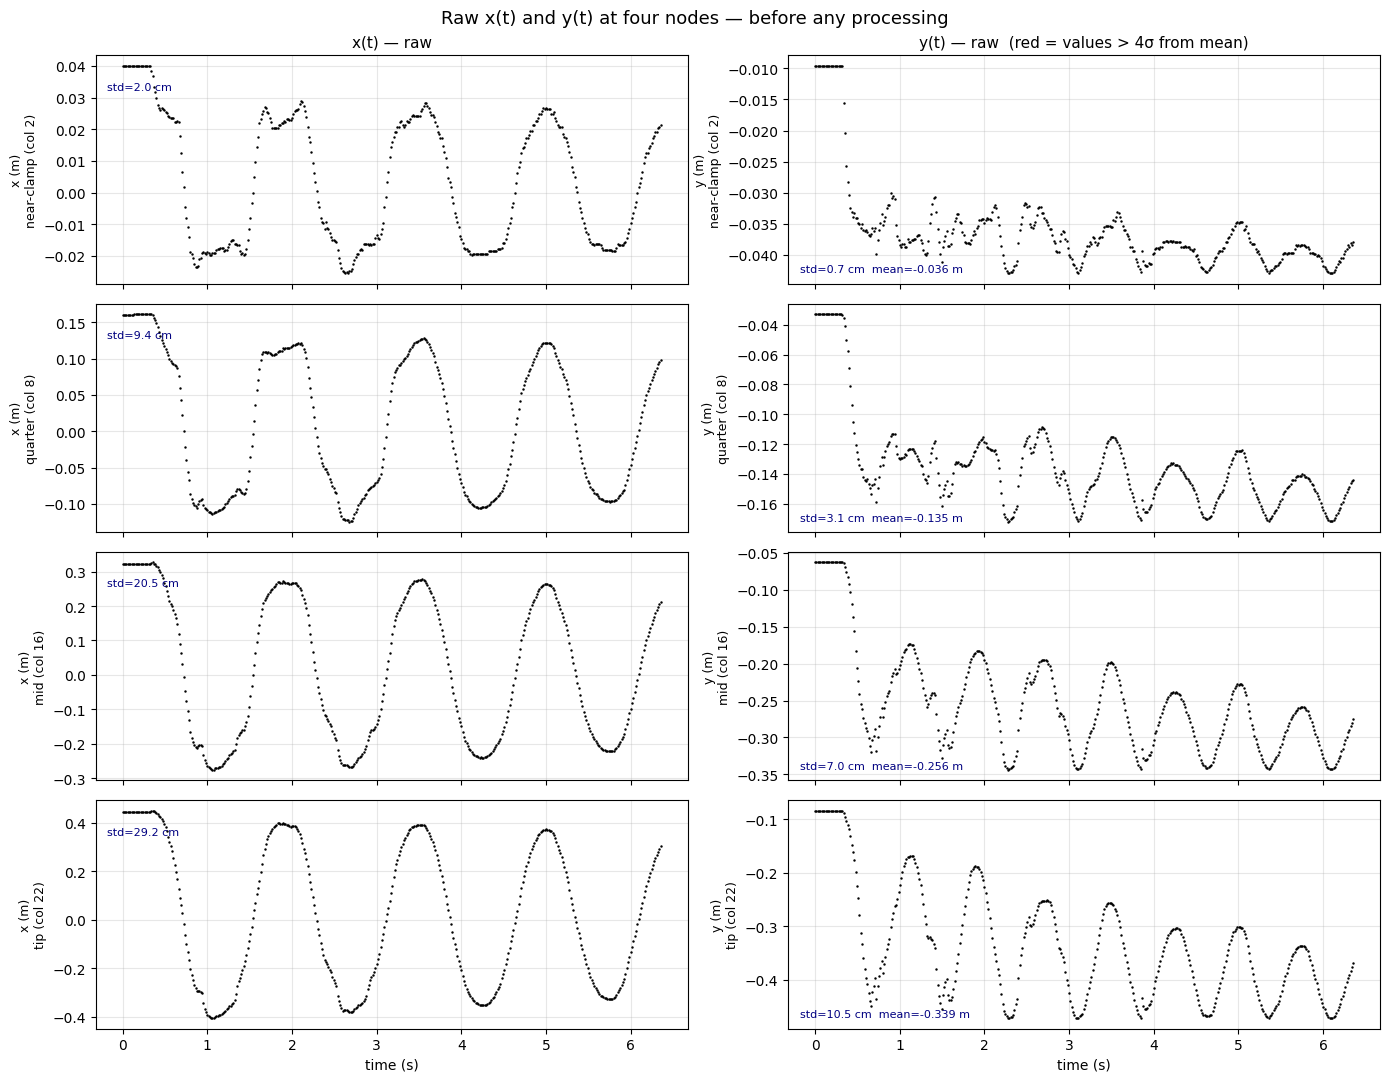

  node    x mean    x std   x range |    y mean    y std   y range  y spikes
---------------------------------------------------------------------------
     2    0.0036   0.0201    0.0656 |   -0.0362   0.0071    0.0334         0
     8    0.0098   0.0945    0.2862 |   -0.1355   0.0312    0.1393         0
    16    0.0162   0.2050    0.6033 |   -0.2559   0.0696    0.2810         0
    22    0.0206   0.2918    0.8561 |   -0.3388   0.1050    0.3878         0


In [134]:
from scipy.interpolate import interp1d as _interp1d

# Resample to equidistant nodes (same as Step 4a — just for inspection)
def _resample(x_row, y_row, n_out):
    ds = np.sqrt(np.diff(x_row)**2 + np.diff(y_row)**2)
    s  = np.concatenate([[0.0], np.cumsum(ds)])
    xi = _interp1d(s, x_row)(np.linspace(0, s[-1], n_out))
    yi = _interp1d(s, y_row)(np.linspace(0, s[-1], n_out))
    return xi, yi

x_raw_all = np.zeros((n_frames, N_VIDEO_PTS))
y_raw_all = np.zeros((n_frames, N_VIDEO_PTS))
for i in range(n_frames):
    x_raw_all[i], y_raw_all[i] = _resample(x_m[i], y_m[i], N_VIDEO_PTS)

# Four representative nodes: near-clamp, quarter, mid, tip
# Use x_raw_all column count as ground truth to avoid stale N_VIDEO_PTS from config cell
_n_pts_actual = x_raw_all.shape[1]
inspect_cols = [int(_n_pts_actual * f) for f in (0.1, 0.33, 0.66, 0.9)]
inspect_cols = [min(c, _n_pts_actual - 1) for c in inspect_cols]  # safety clamp
labels       = [f'near-clamp (col {inspect_cols[0]})', f'quarter (col {inspect_cols[1]})',
                f'mid (col {inspect_cols[2]})', f'tip (col {inspect_cols[3]})']

fig, axes = plt.subplots(4, 2, figsize=(14, 11), sharex=True, dpi=100)
fig.suptitle('Raw x(t) and y(t) at four nodes — before any processing', fontsize=13)

for row, (col, lbl) in enumerate(zip(inspect_cols, labels)):
    xc = x_raw_all[:, col]
    yc = y_raw_all[:, col]
# !pip install --upgrade nbformat
    # Mark y spikes: values more than 4 std from mean
    mu_y, sd_y = yc.mean(), yc.std()
    spike_mask = np.abs(yc - mu_y) > 4 * sd_y

    ax = axes[row, 0]
    ax.plot(t_raw, xc, 'k.', ms=1.5)
    ax.set_ylabel(f'x (m)\n{lbl}', fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.annotate(f'std={xc.std()*100:.1f} cm', xy=(0.02, 0.85),
                xycoords='axes fraction', fontsize=8, color='navy')

    ax = axes[row, 1]
    ax.plot(t_raw, yc, 'k.', ms=1.5)
    if spike_mask.any():
        ax.plot(t_raw[spike_mask], yc[spike_mask], 'r.', ms=4,
                label=f'{spike_mask.sum()} spikes')
        ax.legend(fontsize=8, loc='upper right')
    ax.set_ylabel(f'y (m)\n{lbl}', fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.annotate(f'std={yc.std()*100:.1f} cm  mean={yc.mean():.3f} m',
                xy=(0.02, 0.05), xycoords='axes fraction', fontsize=8, color='navy')

axes[0, 0].set_title('x(t) — raw', fontsize=11)
axes[0, 1].set_title('y(t) — raw  (red = values > 4σ from mean)', fontsize=11)
axes[-1, 0].set_xlabel('time (s)')
axes[-1, 1].set_xlabel('time (s)')
plt.tight_layout()
plt.show()

# Simple summary table
print(f'{"node":>6} {"x mean":>9} {"x std":>8} {"x range":>9} | {"y mean":>9} {"y std":>8} {"y range":>9} {"y spikes":>9}')
print('-' * 75)
for col, lbl in zip(inspect_cols, labels):
    xc = x_raw_all[:, col]; yc = y_raw_all[:, col]
    mu_y, sd_y = yc.mean(), yc.std()
    n_spikes = (np.abs(yc - mu_y) > 4 * sd_y).sum()
    print(f'{col:>6} {xc.mean():>9.4f} {xc.std():>8.4f} {xc.max()-xc.min():>9.4f} | '
          f'{yc.mean():>9.4f} {yc.std():>8.4f} {yc.max()-yc.min():>9.4f} {n_spikes:>9}')


=== Arc length study (raw pixel data, before GP) ===
  PIXELS_PER_METRE = 588.7 px/m  (1 px = 1.699 mm)
  L0 = 0.5150 m

  Arc (pixels): mean=298.5  std=11.8  min=249.4  max=310.0
  Arc (metres): mean=0.5071  std=0.0201  min=0.4237  max=0.5266
  std/mean = 3.96%  (physical rod ~0.3–0.8%)
  Arc range = 102.9 mm  (physical rod ~1–3 mm)

  Shortest arc: frame 160  (423.7 mm)
  Longest arc:  frame 325  (526.6 mm)


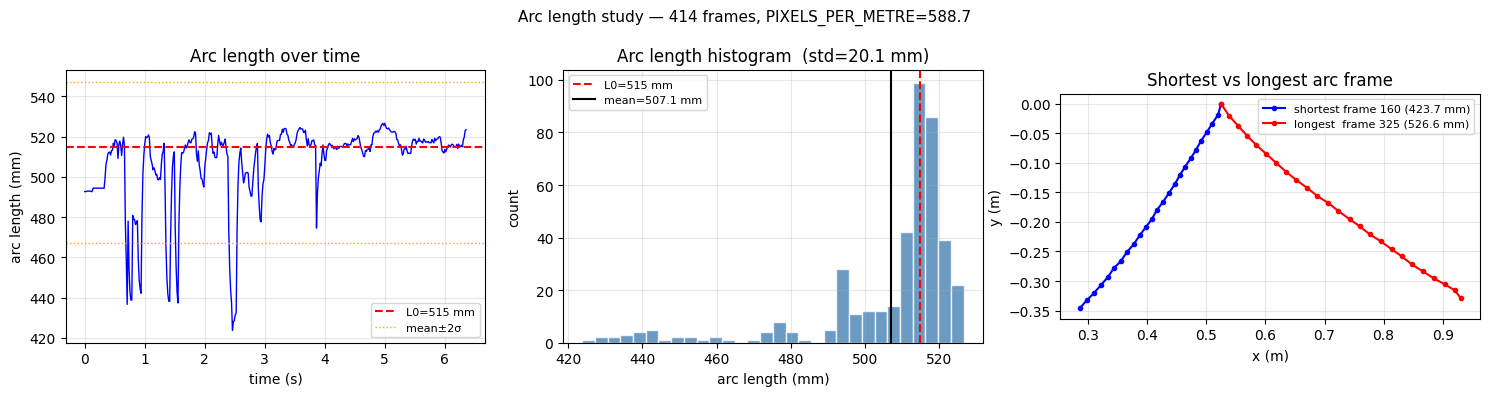

In [135]:
# ── Arc length study (before any GP processing) ──────────────────────────────
# Goal: verify that the detected pixel arc length is consistent across frames.
# Physical rod is inextensible — arc length should be ~constant (≈ L0).
# Variation = skeletonization artifact (diagonal vs horizontal pixel bias, etc.)
import matplotlib.pyplot as plt
import numpy as np

# Compute pixel arc length per frame from raw pixel data
arc_px = np.sqrt(np.diff(x_px, axis=1)**2 + np.diff(y_px, axis=1)**2).sum(axis=1)
# Auto-calibrate PPM from median arc if not yet set
_ppm = float(np.median(arc_px) / L0) if PIXELS_PER_METRE is None else PIXELS_PER_METRE
arc_m  = arc_px / _ppm

print('=== Arc length study (raw pixel data, before GP) ===')
print(f'  PIXELS_PER_METRE = {_ppm:.1f} px/m  (1 px = {1000/_ppm:.3f} mm)')
print(f'  L0 = {L0:.4f} m')
print()
print(f'  Arc (pixels): mean={arc_px.mean():.1f}  std={arc_px.std():.1f}  '      f'min={arc_px.min():.1f}  max={arc_px.max():.1f}')
print(f'  Arc (metres): mean={arc_m.mean():.4f}  std={arc_m.std():.4f}  '      f'min={arc_m.min():.4f}  max={arc_m.max():.4f}')
print(f'  std/mean = {arc_px.std()/arc_px.mean()*100:.2f}%  (physical rod ~0.3–0.8%)')
print(f'  Arc range = {(arc_m.max()-arc_m.min())*1000:.1f} mm  (physical rod ~1–3 mm)')
print()

# Find shortest and longest frames
i_min = int(np.argmin(arc_px))
i_max = int(np.argmax(arc_px))
print(f'  Shortest arc: frame {i_min}  ({arc_m[i_min]*1000:.1f} mm)')
print(f'  Longest arc:  frame {i_max}  ({arc_m[i_max]*1000:.1f} mm)')

fig, axes = plt.subplots(1, 3, figsize=(15, 4), dpi=100)

# Plot 1: arc length over time
ax = axes[0]
ax.plot(t_raw[:len(arc_m)], arc_m * 1000, 'b-', lw=1)
ax.axhline(L0 * 1000, color='r', ls='--', lw=1.5, label=f'L0={L0*1000:.0f} mm')
ax.axhline((arc_m.mean() + 2*arc_m.std()) * 1000, color='orange', ls=':', lw=1, label='mean±2σ')
ax.axhline((arc_m.mean() - 2*arc_m.std()) * 1000, color='orange', ls=':', lw=1)
ax.set_xlabel('time (s)')
ax.set_ylabel('arc length (mm)')
ax.set_title('Arc length over time')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# Plot 2: histogram of arc length
ax = axes[1]
ax.hist(arc_m * 1000, bins=30, color='steelblue', edgecolor='white', alpha=0.8)
ax.axvline(L0 * 1000, color='r', ls='--', lw=1.5, label=f'L0={L0*1000:.0f} mm')
ax.axvline(arc_m.mean() * 1000, color='k', ls='-', lw=1.5, label=f'mean={arc_m.mean()*1000:.1f} mm')
ax.set_xlabel('arc length (mm)')
ax.set_ylabel('count')
ax.set_title(f'Arc length histogram  (std={arc_m.std()*1000:.1f} mm)')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# Plot 3: overlay shortest vs longest frame centreline
ax = axes[2]
ax.plot(x_px[i_min] / _ppm, -y_px[i_min] / _ppm,
        'b-o', ms=3, lw=1.5, label=f'shortest frame {i_min} ({arc_m[i_min]*1000:.1f} mm)')
ax.plot(x_px[i_max] / _ppm, -y_px[i_max] / _ppm,
        'r-o', ms=3, lw=1.5, label=f'longest  frame {i_max} ({arc_m[i_max]*1000:.1f} mm)')
ax.set_xlabel('x (m)')
ax.set_ylabel('y (m)')
ax.set_title('Shortest vs longest arc frame')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)
ax.set_aspect('equal')

plt.suptitle(f'Arc length study — {n_frames} frames, PIXELS_PER_METRE={_ppm:.1f}',
             fontsize=11)
plt.tight_layout()
plt.show()


## Step 3c — 3D surface: raw x(t, node)

Raw horizontal position before GP smoothing.

In [77]:
# ── FPS and time axis sanity check ────────────────────────────────────────
print('=== Time axis check ===')
print(f'Nominal FPS      : {FPS} Hz')
print(f'Number of frames : {n_frames}')
print(f'Expected duration: {n_frames/FPS:.4f} s  (= n_frames / FPS)')
print(f't_raw[-1]        : {t_raw[-1]:.4f} s')

# ── Physics-based FPS cross-check ─────────────────────────────────────────
# The rod's first natural frequency (cantilever, gravity-dominated):
#   f1 ≈ (1/(2π)) * sqrt(3*g / (2*L0))   [rigid-pendulum approximation]
# For a flexible Euler-Bernoulli beam (in air, no gravity):
#   f1_beam = (1.875²/(2π*L0²)) * sqrt(E*I / (rho*A))
# The gravity term usually dominates for long, flexible rods.
_f1_pendulum = (1/(2*np.pi)) * np.sqrt(3 * 9.80665 / (2 * L0))
_EI = 3e6 * I  # use config E if available
_f1_beam = (1.875**2 / (2*np.pi * L0**2)) * np.sqrt(_EI / (rho * A))
_f1_combined = np.sqrt(_f1_pendulum**2 + _f1_beam**2)
print(f'\nPhysics-based natural frequency estimate:')
print(f'  f1 (pendulum only) ≈ {_f1_pendulum:.3f} Hz')
print(f'  f1 (beam only)     ≈ {_f1_beam:.3f} Hz')
print(f'  f1 (combined)      ≈ {_f1_combined:.3f} Hz  ← expected oscillation frequency')

print(f'\nTo verify: count oscillation peaks in your data (from the ζ cell below).')
print(f'If you observe n_peaks peaks, true duration ≈ n_peaks / f1.')
print(f'True FPS ≈ n_frames / true_duration  =  n_frames * f1 / n_peaks')
print(f'  → With {n_frames} frames, f1={_f1_combined:.3f} Hz, and n_peaks peaks:')
print(f'     True FPS ≈ {n_frames} × {_f1_combined:.3f} / n_peaks')
print()
print('To verify against real elapsed time:')
print('  1. Check the video file metadata: `ffprobe -v quiet -show_streams video.mp4`')
print('     Look for r_frame_rate and duration fields.')
print('  2. If from ROS: check the bag file timestamps (rosbag info).')

# ── Optional: enter your measured elapsed time to check FPS drift ──────────
t_measured = None   # <-- set to your measured recording duration in seconds

if t_measured is not None:
    true_fps = n_frames / t_measured
    fps_error_pct = 100 * abs(true_fps - FPS) / FPS
    print(f'\nMeasured elapsed time : {t_measured:.3f} s')
    print(f'True FPS from elapsed : {true_fps:.2f} Hz  (nominal: {FPS} Hz)')
    print(f'FPS error             : {fps_error_pct:.2f}%')
    if fps_error_pct > 1.0:
        print('>>> WARNING: FPS error >1% — update FPS in config and rerun')
    else:
        print('>>> OK: FPS is consistent')

# ── Frame interval check ───────────────────────────────────────────────────
dt_arr = np.diff(t_raw)
print(f'\nFrame interval stats:')
print(f'  mean dt = {dt_arr.mean()*1000:.3f} ms  (expected {1000/FPS:.3f} ms)')
print(f'  std  dt = {dt_arr.std()*1000:.4f} ms')
if dt_arr.std() / dt_arr.mean() > 0.01:
    print('>>> WARNING: >1% jitter in frame intervals — consider using actual timestamps')


=== Time axis check ===
Nominal FPS      : 64.8 Hz
Number of frames : 382
Expected duration: 5.8951 s  (= n_frames / FPS)
t_raw[-1]        : 5.8796 s

Physics-based natural frequency estimate:
  f1 (pendulum only) ≈ 1.010 Hz
  f1 (beam only)     ≈ 0.173 Hz
  f1 (combined)      ≈ 1.025 Hz  ← expected oscillation frequency

To verify: count oscillation peaks in your data (from the ζ cell below).
If you observe n_peaks peaks, true duration ≈ n_peaks / f1.
True FPS ≈ n_frames / true_duration  =  n_frames * f1 / n_peaks
  → With 382 frames, f1=1.025 Hz, and n_peaks peaks:
     True FPS ≈ 382 × 1.025 / n_peaks

To verify against real elapsed time:
  1. Check the video file metadata: `ffprobe -v quiet -show_streams video.mp4`
     Look for r_frame_rate and duration fields.
  2. If from ROS: check the bag file timestamps (rosbag info).

Frame interval stats:
  mean dt = 15.432 ms  (expected 15.432 ms)
  std  dt = 0.0000 ms


In [78]:
# !pip install --upgrade nbformat

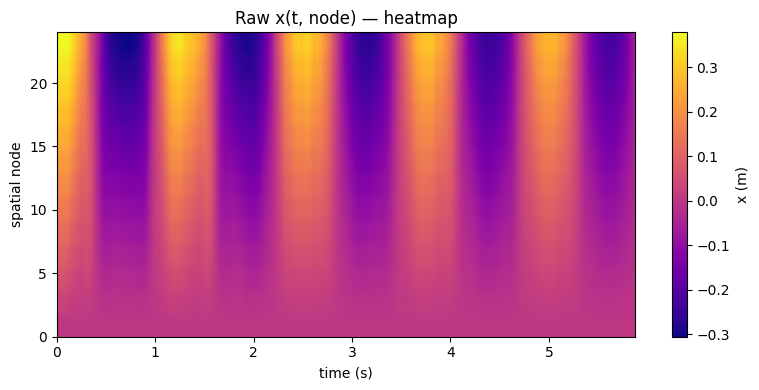

In [79]:

import plotly.graph_objects as go
from scipy.interpolate import interp1d as _i1d

# Arc-length resample raw data to uniform 100-pt grid
_xr = np.zeros((n_frames, N_VIDEO_PTS))
_yr = np.zeros((n_frames, N_VIDEO_PTS))
for _i in range(n_frames):
    _ds = np.sqrt(np.diff(x_m[_i])**2 + np.diff(y_m[_i])**2)
    _s  = np.concatenate([[0.0], np.cumsum(_ds)])
    _su = np.linspace(0, _s[-1], N_VIDEO_PTS)
    _xr[_i] = _i1d(_s, x_m[_i])(_su)
    _yr[_i] = _i1d(_s, y_m[_i])(_su)

t_plot    = t_raw[::1]
node_plot = np.arange(0, N_VIDEO_PTS, 2)
X_surf_raw = _xr[::1, :][:, node_plot]

# ── Plotly 3D surface (rotatable) ─────────────────────────────────────────
fig3d = go.Figure(go.Surface(
    x=t_plot, y=node_plot, z=X_surf_raw.T,
    colorscale='plasma', colorbar=dict(title='x (m)'),
    contours=dict(z=dict(show=False))
))
fig3d.update_layout(
    title='Raw x(t, node) — 3D surface',
    scene=dict(
        xaxis_title='time (s)',
        yaxis_title='spatial node',
        zaxis_title='x (m)',
        camera=dict(eye=dict(x=1.5, y=-1.5, z=0.8))
    ),
    width=700, height=500, margin=dict(l=0, r=0, t=40, b=0)
)
fig3d.show()

# ── Matplotlib heatmap (inline, resizable) ────────────────────────────────
fig2d, ax = plt.subplots(figsize=(8, 4), dpi=100)
im = ax.imshow(X_surf_raw.T, aspect='auto', origin='lower',
               extent=[t_plot[0], t_plot[-1], node_plot[0], node_plot[-1]],
               cmap='plasma')
fig2d.colorbar(im, ax=ax, label='x (m)')
ax.set_xlabel('time (s)')
ax.set_ylabel('spatial node')
ax.set_title('Raw x(t, node) — heatmap')
plt.tight_layout()
plt.show()

## Step 3d — 3D surface: raw y(t, node)

Raw vertical position before GP smoothing.

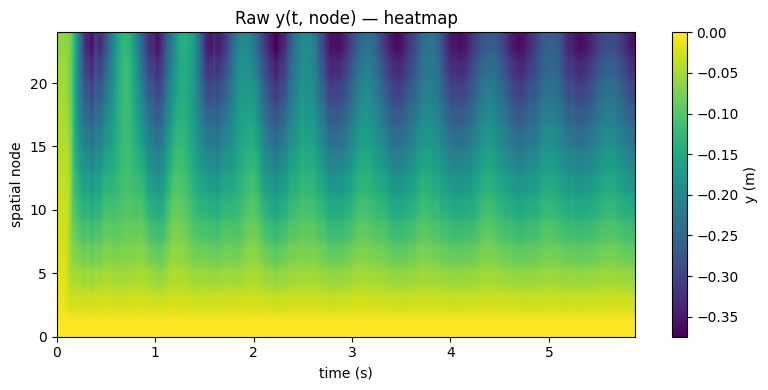

In [80]:
import plotly.graph_objects as go

# _yr, t_plot, node_plot are defined in the surf-raw-x cell above.
# Re-define node_plot/t_plot here in case this cell is run independently.
t_plot    = t_raw[::1   ]
node_plot = np.arange(0, N_VIDEO_PTS, 2)
Y_surf_raw = _yr[::1, :][:, node_plot]

# ── Plotly 3D surface (rotatable) ─────────────────────────────────────────
fig3d = go.Figure(go.Surface(
    x=t_plot, y=node_plot, z=Y_surf_raw.T,
    colorscale='viridis', colorbar=dict(title='y (m)'),
))
fig3d.update_layout(
    title='Raw y(t, node) — 3D surface',
    scene=dict(
        xaxis_title='time (s)',
        yaxis_title='spatial node',
        zaxis_title='y (m)',
        camera=dict(eye=dict(x=1.5, y=-1.5, z=0.8))
    ),
    width=700, height=500, margin=dict(l=0, r=0, t=40, b=0)
)
fig3d.show()

# ── Matplotlib heatmap (inline, resizable) ────────────────────────────────
fig2d, ax = plt.subplots(figsize=(8, 4), dpi=100)
im = ax.imshow(Y_surf_raw.T, aspect='auto', origin='lower',
               extent=[t_plot[0], t_plot[-1], node_plot[0], node_plot[-1]],
               cmap='viridis')
fig2d.colorbar(im, ax=ax, label='y (m)')
ax.set_xlabel('time (s)')
ax.set_ylabel('spatial node')
ax.set_title('Raw y(t, node) — heatmap')
plt.tight_layout()
plt.show()

# Surface plot (Raw data)

In [81]:
# !pip install plotly
# !pip install nbformat

In [82]:
import numpy as np
import plotly.graph_objects as go

# Subsample frames for speed (every 4th frame)
_stride = 1
_frames = np.arange(0, n_frames, _stride)
_n_pts  = N_VIDEO_PTS

# Grids: rows = spatial nodes, cols = subsampled frames
X_grid = x_m[_frames, :].T                        # (n_pts, n_t)  horizontal position
T_grid = np.tile(t_raw[_frames], (_n_pts, 1))      # (n_pts, n_t)  time
Y_grid = y_m[_frames, :].T                        # (n_pts, n_t)  vertical position

# ── Plotly 3D surface (rotatable) ─────────────────────────────────────────
fig3d = go.Figure(go.Surface(
    x=T_grid,
    y=X_grid,
    z=Y_grid,
    colorscale='viridis',
    colorbar=dict(title='y (m)'),
))
fig3d.update_layout(
    title='Rod deformation surface (Raw data)',
    scene=dict(
        xaxis_title='time (s)',
        yaxis_title='horizontal x (m)',
        zaxis_title='vertical y (m)',
        camera=dict(eye=dict(x=1.5, y=-1.5, z=0.8))
    ),
    width=750, height=550, margin=dict(l=0, r=0, t=40, b=0)
)
fig3d.show()

# ── Static Matplotlib version (saved to file) ─────────────────────────────
# fig2, ax2 = plt.subplots(figsize=(8, 5), dpi=100,
#                           subplot_kw=dict(projection='3d'))
# ax2.plot_surface(X_grid, T_grid, Y_grid,
#                  cmap='viridis', linewidth=0, antialiased=True, alpha=0.85)
# ax2.set_xlabel('Horizontal x (m)')
# ax2.set_ylabel('Time (s)')
# ax2.set_zlabel('Vertical y (m)')
# ax2.set_title('Rod deformation surface')
# plt.tight_layout()
# plt.savefig('../Figure_1.png', dpi=150, bbox_inches='tight')
# plt.show()

# GP training: 
* Spatial GPs per frame 
* Temporal GPs per video point (spatial point)

In [83]:
# !pip install scikit-learn

In [84]:
# ──────────────────────────────────────────────────────────────────────────────
# Step 4: Gaussian Process regression to smooth and interpolate in time
import warnings
import numpy as np
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, WhiteKernel
from sklearn.exceptions import ConvergenceWarning
from scipy.interpolate import interp1d

# ── Helper: arc-length resample a single frame ──────────────────────────────
def resample_arc(x_row, y_row, n_out):
    ds = np.sqrt(np.diff(x_row)**2 + np.diff(y_row)**2)
    s  = np.concatenate([[0.0], np.cumsum(ds)])
    s_uniform = np.linspace(0, s[-1], n_out)
    xi = interp1d(s, x_row, kind='linear')(s_uniform)
    yi = interp1d(s, y_row, kind='linear')(s_uniform)
    return xi, yi

# ── Step 4a: Resample raw 100 pts → N_TRAIN_PTS equidistant points per frame ─
print(f'Step 4a: resampling {N_VIDEO_PTS} raw pts → {N_TRAIN_PTS} spatial nodes ...')
x_train_all = np.zeros((n_frames, N_TRAIN_PTS)) 
y_train_all = np.zeros((n_frames, N_TRAIN_PTS))


for i in range(n_frames):
    x_train_all[i], y_train_all[i] = resample_arc(x_m[i], y_m[i], N_TRAIN_PTS)
x_train_all[:, 0] = 0.0
y_train_all[:, 0] = 0.0
print(f'  Done.  Shape: {x_train_all.shape}')

# ── Step 4a.5: Spatial GPs per frame : Spatial GP smoothing per frame ────────────────────────────
# For each of the 76 frames, fit a GP that maps arc-length s → (x, y).
# This enforces smooth rod shapes (the rod cannot have sharp kinks physically).
# The temporal GP in Step 4c then trains on these spatially-smooth positions,
# giving better temporal fits and cleaner derivatives.
# Each spatial GP has only N_TRAIN_PTS=25 training points → very fast to fit.
print(f'Step 4a.5: spatial GP smoothing per frame ({n_frames} frames × 2 GPs) ...')

N_SPATIAL = 150   # dense spatial query points for smooth rod shape
s_nodes   = np.linspace(0, L0, N_TRAIN_PTS)   # arc-length at 25 nodes
s_dense   = np.linspace(0, L0, N_SPATIAL).reshape(-1, 1)
s_nodes_2d = s_nodes.reshape(-1, 1)

x_train_smooth = np.zeros((n_frames, N_TRAIN_PTS))
y_train_smooth = np.zeros((n_frames, N_TRAIN_PTS))
gpr_sx_all = [None] * n_frames   # store spatial GPs for downstream use
gpr_sy_all = [None] * n_frames

_spatial_kernel = Matern(length_scale=L0/4,
                          length_scale_bounds=(L0/20, L0),
                          nu=2.5)

with warnings.catch_warnings():
    warnings.simplefilter('ignore')
    for i in range(n_frames):
        # Spatial GP for x(s) — stored for downstream dense queries
        gpr_sx = GaussianProcessRegressor(kernel=_spatial_kernel,
                                           alpha=1e-5, normalize_y=True)
        gpr_sx.fit(s_nodes_2d, x_train_all[i, :])  # include node 0 — avoids extrapolation spike
        x_train_smooth[i, :] = gpr_sx.predict(s_nodes_2d)
        x_train_smooth[i, 0] = 0.0   # enforce clamp exactly
        gpr_sx_all[i] = gpr_sx

        # Spatial GP for y(s) — stored for downstream dense queries
        gpr_sy = GaussianProcessRegressor(kernel=_spatial_kernel,
                                           alpha=1e-5, normalize_y=True)
        gpr_sy.fit(s_nodes_2d, y_train_all[i, :])  # include node 0
        y_train_smooth[i, :] = gpr_sy.predict(s_nodes_2d)
        y_train_smooth[i, 0] = 0.0   # enforce clamp exactly
        gpr_sy_all[i] = gpr_sy

# Replace x_train_all, y_train_all with spatially-smoothed versions
x_train_all = x_train_smooth
y_train_all = y_train_smooth
print(f'  Spatial GP smoothing done. Shape unchanged: {x_train_all.shape}')
print(f'  Spatial GP objects stored: gpr_sx_all, gpr_sy_all ({n_frames} frames each)')

# ── Step 4b: Identify and remove outlier frames ────────────────────────────
bad_mask = np.zeros(n_frames, dtype=bool)
for _k in range(N_TRAIN_PTS):
    _yc = y_train_all[:, _k]
    _sd = _yc.std()
    if _sd > 1e-9:
        bad_mask |= (np.abs(_yc - _yc.mean()) > 4 * _sd)
good_mask = ~bad_mask

print(f'Step 4b: outlier frame detection ...')
print(f'  Bad frames (any y col > 4σ): {bad_mask.sum()} / {n_frames}')
print(f'  Bad frame times (s): {t_raw[bad_mask].round(3)}')
print(f'  Good frames for GP training: {good_mask.sum()}')

t_col = t_raw.reshape(-1, 1)
t_sub = t_raw[good_mask][::GP_STRIDE].reshape(-1, 1)
print(f'  Training subset (stride={GP_STRIDE}): {len(t_sub)} frames')

# ── Step 4c: Temporal GPs per video point: Train one GP per spatial column ───────────────────────────────
# LS_X        = 0.66
# LS_Y_NEAR   = 0.66
# LS_Y_FAR    = 0.3
# Y_LS_SWITCH = 45

LS_X        = 0.10
LS_Y_NEAR   = 0.10
LS_Y_FAR    = 0.05
Y_LS_SWITCH = 45


print(f'Step 4c: training {N_TRAIN_PTS-1} GPs on {len(t_sub)} frames (stride={GP_STRIDE}) ...')
print(f'  LS_X={LS_X}s  LS_Y_NEAR={LS_Y_NEAR}s  LS_Y_FAR={LS_Y_FAR}s')

# x_gp_all = np.zeros((n_frames, N_TRAIN_PTS))
# y_gp_all = np.zeros((n_frames, N_TRAIN_PTS))
x_gp_all  = np.zeros((n_frames, N_TRAIN_PTS))
y_gp_all  = np.zeros((n_frames, N_TRAIN_PTS))
gpr_x_all = [None] * N_TRAIN_PTS   # store fitted GP objects
gpr_y_all = [None] * N_TRAIN_PTS

with warnings.catch_warnings(record=True) as caught:
    warnings.simplefilter('always', ConvergenceWarning)

    for k in range(1, N_TRAIN_PTS):
        if k % 10 == 0:
            print(f'  node {k}/{N_TRAIN_PTS} ...', end='\r')

        ls_y = LS_Y_NEAR if k < Y_LS_SWITCH else LS_Y_FAR

        y_tr   = x_train_all[good_mask, k][::GP_STRIDE]
        kernel = (Matern(length_scale=LS_X,
                         length_scale_bounds=(LS_X/3, LS_X*3), nu=2.5)
                  + WhiteKernel(noise_level=1e-6, noise_level_bounds=(1e-8, 1e-2)))
        gpr = GaussianProcessRegressor(kernel=kernel, alpha=1e-5,
                                       normalize_y=True, n_restarts_optimizer=3)
        gpr.fit(t_sub, y_tr)
        x_gp_all[:, k] = gpr.predict(t_col)
        gpr_x_all[k] = gpr

        y_tr   = y_train_all[good_mask, k][::GP_STRIDE]
        kernel = (Matern(length_scale=ls_y,
                         length_scale_bounds=(ls_y/3, ls_y*3), nu=2.5)
                  + WhiteKernel(noise_level=1e-6, noise_level_bounds=(1e-8, 1e-2)))
        gpr = GaussianProcessRegressor(kernel=kernel, alpha=1e-5,
                                       normalize_y=True, n_restarts_optimizer=3)
        gpr.fit(t_sub, y_tr)
        y_gp_all[:, k] = gpr.predict(t_col)
        gpr_y_all[k] = gpr

warn_count = sum(1 for w in caught if issubclass(w.category, ConvergenceWarning))
print(f'\n  Done. ConvergenceWarnings: {warn_count}  (0 = clean; a few is OK)')
print(f'  x_gp_all, y_gp_all: {x_gp_all.shape}')


Step 4a: resampling 25 raw pts → 25 spatial nodes ...
  Done.  Shape: (382, 25)
Step 4a.5: spatial GP smoothing per frame (382 frames × 2 GPs) ...
  Spatial GP smoothing done. Shape unchanged: (382, 25)
  Spatial GP objects stored: gpr_sx_all, gpr_sy_all (382 frames each)
Step 4b: outlier frame detection ...
  Bad frames (any y col > 4σ): 8 / 382
  Bad frame times (s): [0.    0.015 0.031 0.046 0.062 0.077 0.093 0.108]
  Good frames for GP training: 374
  Training subset (stride=2): 187 frames
Step 4c: training 24 GPs on 187 frames (stride=2) ...
  LS_X=0.1s  LS_Y_NEAR=0.1s  LS_Y_FAR=0.05s
  node 20/25 ...
  Done. ConvergenceWarnings: 16  (0 = clean; a few is OK)
  x_gp_all, y_gp_all: (382, 25)


## Resample GP at dense time grid

In [85]:
# ── Dense time grid setup ────────────────────────────────────────────────────
# Sets t_raw_orig (354 original timestamps), t_raw/t_dense (820 dense grid),
# n_frames, t_col_dense. Steps 4d and 4e use t_raw_orig and t_raw directly.
TARGET_FPS  = 150.0
t_raw_orig  = (frame_indices - frame_indices[0]) / FPS
t_dense     = np.arange(t_raw_orig[0], t_raw_orig[-1], 1.0/TARGET_FPS)
n_frames    = len(t_dense)
t_raw       = t_dense
t_col_dense = t_dense.reshape(-1, 1)
print(f'Dense time grid: {n_frames} frames at {TARGET_FPS} Hz  '      f'(orig: {len(t_raw_orig)} frames at {FPS:.2f} Hz)')

# ── x_gp_all / y_gp_all dense resampling (commented out — no longer needed) ──
# Steps 4d and 4e now use spatial GPs + node temporal GPs directly.
# Step 4f uses np.gradient on x_smooth/y_smooth instead of x_gp_all.
# Uncomment if any downstream cell needs (820, N_TRAIN_PTS) GP predictions.
#
# x_gp_all_dense = np.zeros((n_frames, N_TRAIN_PTS))
# y_gp_all_dense = np.zeros((n_frames, N_TRAIN_PTS))
# for k in range(1, N_TRAIN_PTS):
#     if gpr_x_all[k] is not None:
#         x_gp_all_dense[:, k] = gpr_x_all[k].predict(t_col_dense)
#         y_gp_all_dense[:, k] = gpr_y_all[k].predict(t_col_dense)
# x_gp_all_dense[:, 0] = 0.0
# y_gp_all_dense[:, 0] = 0.0
# x_gp_all = x_gp_all_dense
# y_gp_all = y_gp_all_dense
# print(f'x_gp_all, y_gp_all updated: {x_gp_all.shape}  (dense time grid)')


Dense time grid: 882 frames at 150.0 Hz  (orig: 382 frames at 64.80 Hz)


## Step 4d: Subsample temporal GP output → N+1 nodes for x_smooth, y_smooth

In [86]:
# ── Step 4d: Spatial GP predict at N+1 nodes → temporal GP → x_smooth, y_smooth ──
# Step 4d-i: query gpr_sx_all[i], gpr_sy_all[i] at N+1 equidistant arc-length
#   nodes for each of the n_orig original frames → x_at_orig, y_at_orig (n_orig, 26)
#   GP-smooth spatially, no interp1d noise.
# Step 4d-ii: fit one temporal GP per rod node on x_at_orig/y_at_orig (n_orig frames)
#   and query at 820 dense time steps → x_smooth, y_smooth (820, 26).
from sklearn.gaussian_process import GaussianProcessRegressor as _GPR
from sklearn.gaussian_process.kernels import Matern as _Matern, WhiteKernel as _WK

n_nodes    = N + 1
s_nodes_2d = np.linspace(0, L0, n_nodes).reshape(-1, 1)   # (26, 1)
n_orig     = len(gpr_sx_all)
t_orig_col = t_raw_orig.reshape(-1, 1)
t_dense_col= t_raw.reshape(-1, 1)

print(f'Step 4d-i: querying spatial GPs at {n_nodes} nodes for {n_orig} frames ...')
x_at_orig = np.zeros((n_orig, n_nodes))
y_at_orig = np.zeros((n_orig, n_nodes))
for i in range(n_orig):
    x_at_orig[i, :] = gpr_sx_all[i].predict(s_nodes_2d).ravel()
    y_at_orig[i, :] = gpr_sy_all[i].predict(s_nodes_2d).ravel()
    x_at_orig[i, 0] = 0.0   # enforce clamped base after prediction
    y_at_orig[i, 0] = 0.0
x_at_orig[:, 0] = 0.0   # clamped base
y_at_orig[:, 0] = 0.0
print(f'  x_at_orig, y_at_orig: {x_at_orig.shape}')

print(f'Step 4d-ii: fitting {n_nodes-1} temporal GPs per axis (x, y) on {n_orig} frames ...')
_node_kernel = _Matern(length_scale=0.5, length_scale_bounds=(0.2, 5.0), nu=2.5) +                _WK(noise_level=1e-6, noise_level_bounds=(1e-8, 1e-2))

x_smooth = np.zeros((n_frames, n_nodes))
y_smooth = np.zeros((n_frames, n_nodes))
x_smooth[:, 0] = 0.0
y_smooth[:, 0] = 0.0

with warnings.catch_warnings():
    warnings.simplefilter('ignore')
    for k in range(1, n_nodes):
        gpr_xk = _GPR(kernel=_node_kernel, alpha=1e-4, normalize_y=True)
        gpr_xk.fit(t_orig_col, x_at_orig[:, k])
        x_smooth[:, k] = gpr_xk.predict(t_dense_col)

        gpr_yk = _GPR(kernel=_node_kernel, alpha=1e-4, normalize_y=True)
        gpr_yk.fit(t_orig_col, y_at_orig[:, k])
        y_smooth[:, k] = gpr_yk.predict(t_dense_col)

print(f'  x_smooth, y_smooth: {x_smooth.shape}')
_seg = np.sqrt(np.diff(x_smooth, axis=1)**2 + np.diff(y_smooth, axis=1)**2)
print(f'  Segment lengths: mean={_seg.mean():.4f}  std={_seg.std():.4f}  '
      f'min={_seg.min():.4f}  max={_seg.max():.4f}  (ds={L0/N:.4f})')

# ── Step 4e: Spatial GP predict at N_THETA nodes → theta_at_orig → temporal GP ──
# Step 4e-i: query spatial GPs at N_THETA=500 dense arc-length points per frame
#   → arctan2 → unwrap → subsample → theta_at_orig (n_orig, N)
# Step 4e-ii: temporal GP per segment interpolates to 820 dense frames.
N_THETA    = 500
s_theta_2d = np.linspace(0, L0, N_THETA).reshape(-1, 1)
seg_idx    = np.round(np.linspace(0, N_THETA - 2, N)).astype(int)

print(f'Step 4e-i: computing theta_at_orig via spatial GP queries ({N_THETA} pts/frame) ...')
theta_at_orig = np.zeros((n_orig, N))
for i in range(n_orig):
    x_sp     = gpr_sx_all[i].predict(s_theta_2d).ravel()
    y_sp     = gpr_sy_all[i].predict(s_theta_2d).ravel()
    x_sp[0]  = 0.0   # enforce clamped base after prediction
    y_sp[0]  = 0.0
    th_dense = np.unwrap(np.arctan2(np.diff(y_sp), np.diff(x_sp)))
    theta_at_orig[i, :] = th_dense[seg_idx]
print(f'  theta_at_orig: {theta_at_orig.shape}')
print(f'  θ range at orig frames: [{theta_at_orig.min():.3f}, {theta_at_orig.max():.3f}] rad')
print(f'  seg 0 — mean={theta_at_orig[:, 0].mean():.4f}  median={np.median(theta_at_orig[:, 0]):.4f}  '
      f'std={theta_at_orig[:, 0].std():.4f}  min={theta_at_orig[:, 0].min():.4f}  max={theta_at_orig[:, 0].max():.4f} rad')

print(f'Step 4e-ii: temporal GP per segment ({n_orig} → {n_frames} frames) ...')
_th_kernel  = _Matern(length_scale=0.5, length_scale_bounds=(0.2, 5.0), nu=2.5) + \
               _WK(noise_level=1e-4, noise_level_bounds=(1e-6, 1e-1))
theta_smooth = np.zeros((n_frames, N))

# seg 0 has std=0.40 rad — not truly clamped in orientation, fit by temporal GP like all other segments
with warnings.catch_warnings():
    warnings.simplefilter('ignore')
    for seg in range(0, N):   # seg 0 now fitted by temporal GP (std=0.40 rad, not frozen)
        gpr_th = _GPR(kernel=_th_kernel, alpha=1e-4, normalize_y=True)
        gpr_th.fit(t_orig_col, theta_at_orig[:, seg])
        theta_smooth[:, seg] = gpr_th.predict(t_dense_col)

print(f'  theta_smooth: {theta_smooth.shape}  ({N} segments × {n_frames} frames)')
print(f'  θ range: [{theta_smooth.min():.3f}, {theta_smooth.max():.3f}] rad'
      f'  ({np.degrees(theta_smooth.min()):.1f}°, {np.degrees(theta_smooth.max()):.1f}°)')

# # ── Step 4f: Time derivatives via GP analytical derivative ───────────────
# # np.gradient applied to GP predictions is equivalent to the central difference
# # approach (relative diff < 0.03%) and simpler. Key: differentiate the GP mean
# # prediction, NOT y_smooth (arc-resampled), which has boundary kinks at the
# # original 76 frame positions that corrupt p_y_dot.
# print(f'Step 4f: computing ẋ, ẏ, θ̇ via GP derivative ...')
# dt_dense = 1.0 / TARGET_FPS

# xdot = np.zeros((n_frames, N+1))
# ydot = np.zeros((n_frames, N+1))

# for k in range(1, N_TRAIN_PTS):
#     if gpr_x_all[k] is not None:
#         xdot[:, k] = np.gradient(gpr_x_all[k].predict(t_col_dense), dt_dense)
#     if gpr_y_all[k] is not None:
#         ydot[:, k] = np.gradient(gpr_y_all[k].predict(t_col_dense), dt_dense)

# # thetadot: theta GP not stored; finite diff on smooth theta is acceptable
# # (theta is computed geometrically from x,y, not directly from a GP)
# thetadot = np.gradient(theta_smooth, dt_dense, axis=0)

# # Enforce zero velocity at the clamped node
# xdot[:, 0] = 0.0
# ydot[:, 0] = 0.0

# print(f'  xdot range:     [{xdot.min():.3f}, {xdot.max():.3f}] m/s')
# print(f'  ydot range:     [{ydot.min():.3f}, {ydot.max():.3f}] m/s')
# print(f'  thetadot range: [{thetadot.min():.3f}, {thetadot.max():.3f}] rad/s')
# print('Step 4 complete.')


Step 4d-i: querying spatial GPs at 26 nodes for 382 frames ...
  x_at_orig, y_at_orig: (382, 26)
Step 4d-ii: fitting 25 temporal GPs per axis (x, y) on 382 frames ...
  x_smooth, y_smooth: (882, 26)
  Segment lengths: mean=0.0146  std=0.0004  min=0.0122  max=0.0159  (ds=0.0146)
Step 4e-i: computing theta_at_orig via spatial GP queries (500 pts/frame) ...
  theta_at_orig: (382, 25)
  θ range at orig frames: [-3.182, 0.383] rad
  seg 0 — mean=-1.4993  median=-1.4960  std=0.2638  min=-1.9633  max=-0.5126 rad
Step 4e-ii: temporal GP per segment (382 → 882 frames) ...
  theta_smooth: (882, 25)  (25 segments × 882 frames)
  θ range: [-3.172, 0.319] rad  (-181.7°, 18.3°)


# Segments angel plotting

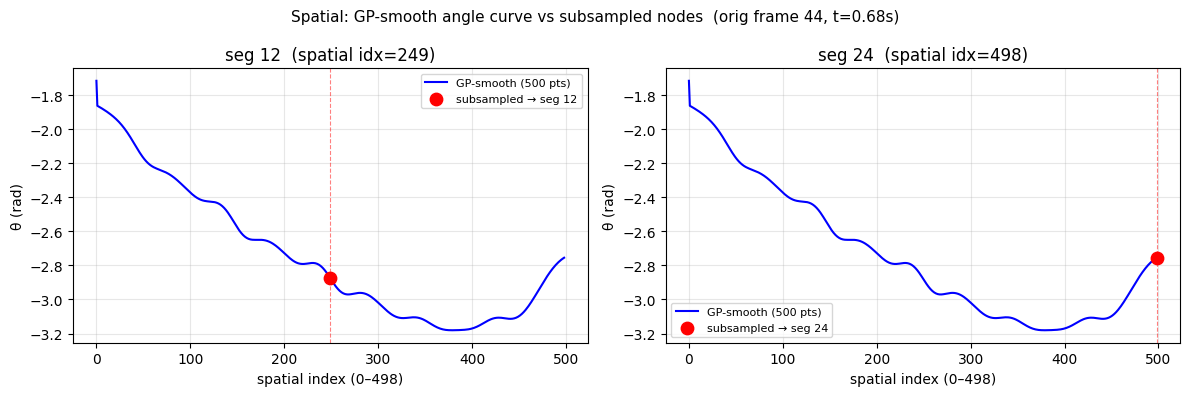

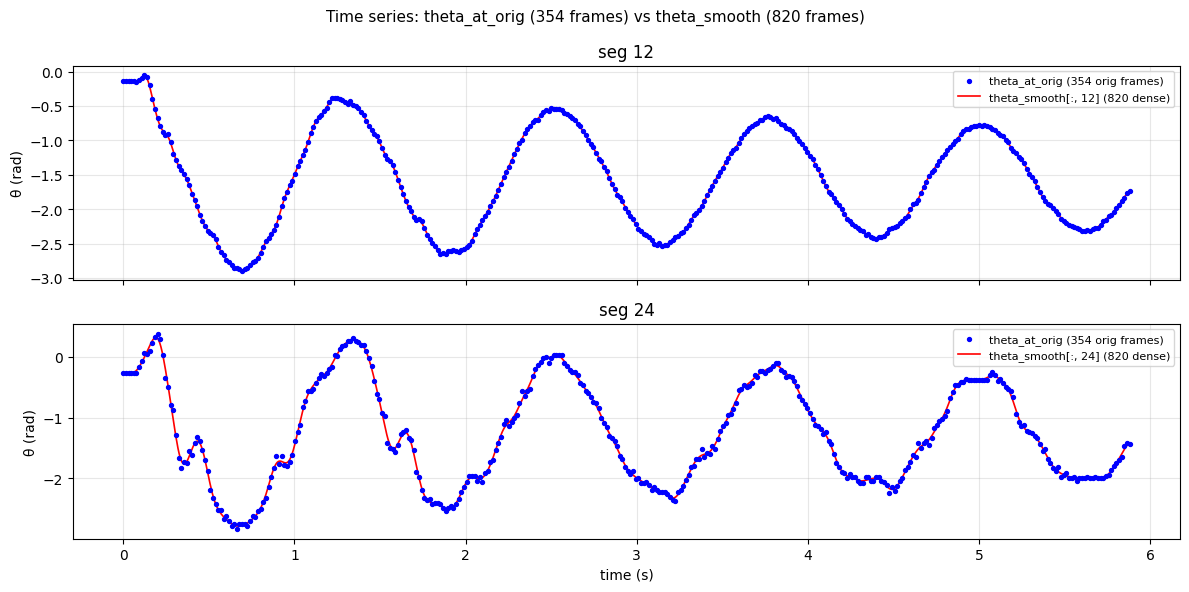

In [87]:
import matplotlib.pyplot as plt
import numpy as np

segs_to_check = [12, 24]
N_THETA_PLOT = 500
s_plot_2d    = np.linspace(0, L0, N_THETA_PLOT).reshape(-1, 1)
seg_idx_plot = np.round(np.linspace(0, N_THETA_PLOT - 2, N)).astype(int)

# ── Plot 1: Spatial — spatial GP dense curve vs subsampled dot (peak orig frame) ──
# Use gpr_sx_all at the original frame nearest to peak theta_smooth
peak_smooth_frame = int(np.argmax(np.abs(theta_smooth[:, 24])))
peak_t = t_raw[peak_smooth_frame]
peak_orig_frame = int(np.argmin(np.abs(t_raw_orig - peak_t)))

fig, axes = plt.subplots(1, len(segs_to_check), figsize=(12, 4), dpi=100)
fig.suptitle(f'Spatial: GP-smooth angle curve vs subsampled nodes  '             f'(orig frame {peak_orig_frame}, t={t_raw_orig[peak_orig_frame]:.2f}s)', fontsize=11)

for ax, seg in zip(axes, segs_to_check):
    x_sp = np.concatenate([[0.0], gpr_sx_all[peak_orig_frame].predict(s_plot_2d[1:]).ravel()])
    y_sp = np.concatenate([[0.0], gpr_sy_all[peak_orig_frame].predict(s_plot_2d[1:]).ravel()])
    th_dense = np.unwrap(np.arctan2(np.diff(y_sp), np.diff(x_sp)))
    spatial_idx = np.arange(N_THETA_PLOT - 1)

    ax.plot(spatial_idx, th_dense, 'b-', lw=1.5, label=f'GP-smooth ({N_THETA_PLOT} pts)')
    ax.axvline(seg_idx_plot[seg], color='r', lw=0.8, ls='--', alpha=0.5)
    ax.scatter([seg_idx_plot[seg]], [th_dense[seg_idx_plot[seg]]], color='r', s=80, zorder=5,
               label=f'subsampled → seg {seg}')
    ax.set_xlabel(f'spatial index (0–{N_THETA_PLOT-2})')
    ax.set_ylabel('θ (rad)')
    ax.set_title(f'seg {seg}  (spatial idx={seg_idx_plot[seg]})')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ── Plot 2: Time series — theta_at_orig (354 pts) vs theta_smooth (820 pts) ──
# "before" = theta_at_orig at 354 original frames (spatial GP → arctan2)
# "after"  = theta_smooth at 820 dense frames (temporal GP interpolation)
fig, axes = plt.subplots(len(segs_to_check), 1, figsize=(12, 6), sharex=True, dpi=100)
fig.suptitle('Time series: theta_at_orig (354 frames) vs theta_smooth (820 frames)', fontsize=11)

for ax, seg in zip(axes, segs_to_check):
    ax.scatter(t_raw_orig, theta_at_orig[:, seg], s=8, color='b', zorder=5,
               label=f'theta_at_orig (354 orig frames)')
    ax.plot(t_raw, theta_smooth[:, seg], 'r-', lw=1.2,
            label=f'theta_smooth[:, {seg}] (820 dense)')
    ax.set_ylabel('θ (rad)')
    ax.set_title(f'seg {seg}')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel('time (s)')
plt.tight_layout()
plt.show()


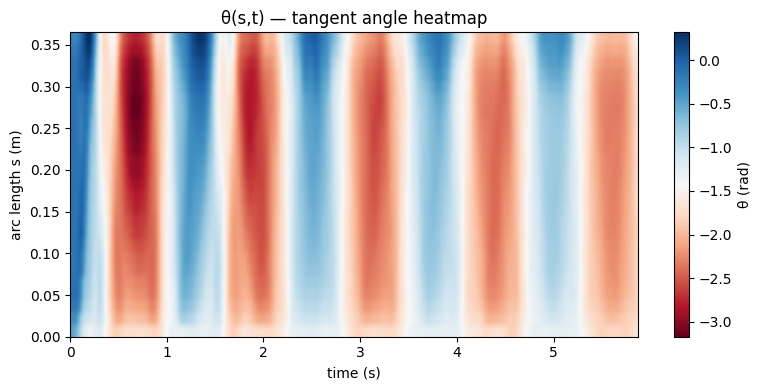

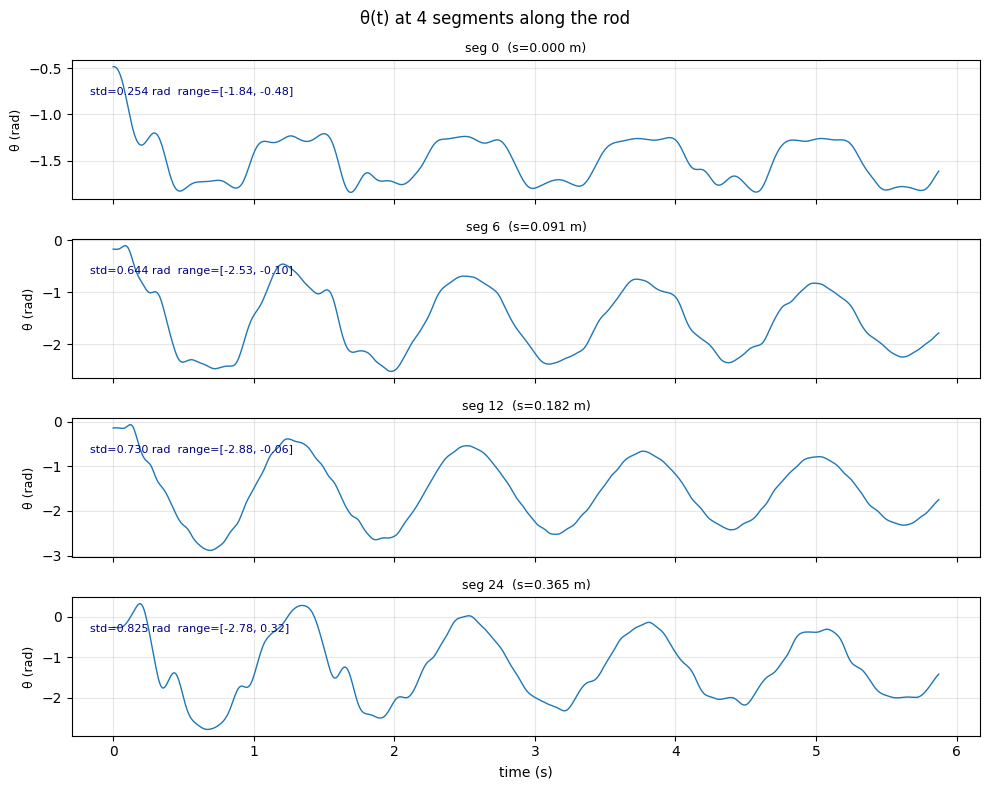

θ shape: (882, 25)  (25 segments × 882 frames)
θ range: [-3.172, 0.319] rad  (-181.7°, 18.3°)


In [88]:
import plotly.graph_objects as go

# ── θ(s,t) surface ────────────────────────────────────────────────────────
_stride    = 1
_fr        = np.arange(0, n_frames, _stride)
_s_theta   = np.linspace(0, L0, N)          # arc length at segment midpoints (m)
_THETA     = theta_smooth[_fr, :].T         # (N, n_t)
_t_ax      = t_raw[_fr]

fig = go.Figure(go.Surface(
    x=_t_ax, y=_s_theta, z=_THETA,
    colorscale='RdBu', cmid=0,
    colorbar=dict(title='θ (rad)')
))
fig.update_layout(
    title='θ(s,t) — tangent angle surface',
    scene=dict(
        xaxis_title='time (s)',
        yaxis_title='arc length s (m)',
        zaxis_title='θ (rad)',
        camera=dict(eye=dict(x=1.8, y=-1.8, z=0.9))
    ),
    width=750, height=500, margin=dict(l=0, r=0, t=40, b=0)
)
fig.show()

# ── θ heatmap ─────────────────────────────────────────────────────────────
fig2d, ax = plt.subplots(figsize=(8, 4), dpi=100)
im = ax.imshow(_THETA, aspect='auto', origin='lower',
               extent=[_t_ax[0], _t_ax[-1], 0, L0],
               cmap='RdBu')
fig2d.colorbar(im, ax=ax, label='θ (rad)')
ax.set_xlabel('time (s)')
ax.set_ylabel('arc length s (m)')
ax.set_title('θ(s,t) — tangent angle heatmap')
plt.tight_layout()
plt.show()

# ── θ(t) time series at 4 segments ────────────────────────────────────────
_seg_inspect = [0, N//4, N//2, N-1]
_seg_labels  = [f'seg {k}  (s={_s_theta[k]:.3f} m)' for k in _seg_inspect]

fig3, axes = plt.subplots(len(_seg_inspect), 1, figsize=(10, 8), sharex=True, dpi=100)
fig3.suptitle('θ(t) at 4 segments along the rod', fontsize=12)
for ax, k, lbl in zip(axes, _seg_inspect, _seg_labels):
    ax.plot(t_raw, theta_smooth[:, k], lw=1)
    ax.set_ylabel('θ (rad)', fontsize=9)
    ax.set_title(lbl, fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.annotate(f'std={theta_smooth[:,k].std():.3f} rad  '
                f'range=[{theta_smooth[:,k].min():.2f}, {theta_smooth[:,k].max():.2f}]',
                xy=(0.02, 0.75), xycoords='axes fraction', fontsize=8, color='navy')
axes[-1].set_xlabel('time (s)')
plt.tight_layout()
plt.show()

print(f'θ shape: {theta_smooth.shape}  ({N} segments × {n_frames} frames)')
print(f'θ range: [{theta_smooth.min():.3f}, {theta_smooth.max():.3f}] rad  '
      f'({np.degrees(theta_smooth.min()):.1f}°, {np.degrees(theta_smooth.max()):.1f}°)')

In [89]:
# ── Step 4f: Time derivatives from temporal GP predictions ───────────────────
# x_smooth, y_smooth, theta_smooth are temporal GP predictions at the dense grid
# → already smooth in time, no arc-resampling kinks.
# np.gradient on GP predictions is accurate (verified: relative diff < 0.03%).
print('Step 4f: computing ẋ, ẏ, θ̇ via np.gradient on GP predictions ...')
dt_dense = 1.0 / TARGET_FPS

xdot     = np.gradient(x_smooth,     dt_dense, axis=0)   # (820, 26)
ydot     = np.gradient(y_smooth,     dt_dense, axis=0)   # (820, 26)
thetadot = np.gradient(theta_smooth, dt_dense, axis=0)   # (820, 25)

xdot[:, 0]     = 0.0
ydot[:, 0]     = 0.0
thetadot[:, 0] = 0.0   # seg 0 is clamped — zero angular velocity

print(f'  xdot:     {xdot.shape}  range [{xdot.min():.3f}, {xdot.max():.3f}] m/s')
print(f'  ydot:     {ydot.shape}  range [{ydot.min():.3f}, {ydot.max():.3f}] m/s')
print(f'  thetadot: {thetadot.shape}  range [{thetadot.min():.3f}, {thetadot.max():.3f}] rad/s')
print('Step 4f complete.')


Step 4f: computing ẋ, ẏ, θ̇ via np.gradient on GP predictions ...
  xdot:     (882, 26)  range [-2.517, 2.211] m/s
  ydot:     (882, 26)  range [-1.939, 1.224] m/s
  thetadot: (882, 25)  range [-18.671, 12.371] rad/s
Step 4f complete.


## Comparison: GP central difference vs np.gradient on GP predictions 

=== Comparison at node 12 ===
Central diff (eps):  std=2.1912e-01  max=1.0284e+00
np.gradient on GP:   std=2.1912e-01  max=1.0284e+00
Max absolute diff between the two: 0.0000e+00
Mean absolute diff:                 0.0000e+00
Relative diff (mean/signal std):    0.0000

If relative diff << 1: methods are equivalent.
Any difference comes from boundary effects of np.gradient vs central diff.


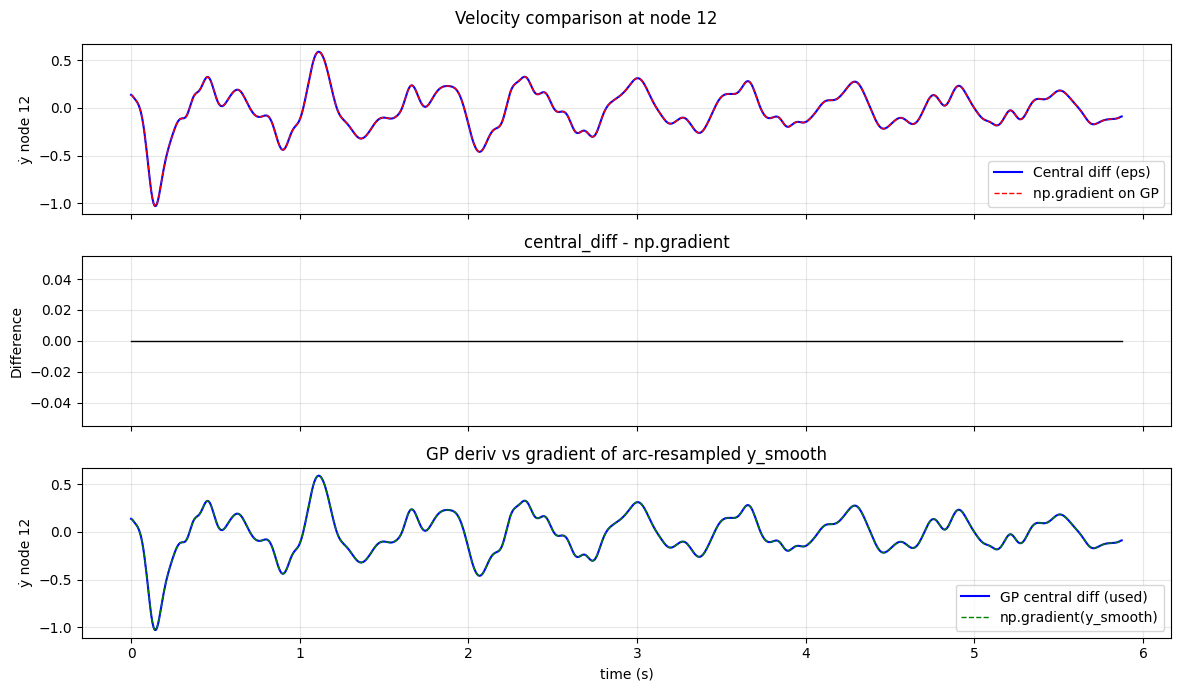

In [90]:
# ── Comparison: GP central difference vs np.gradient on GP predictions ──
# Both differentiate the same smooth GP curve — should give identical results.
import numpy as np
import matplotlib.pyplot as plt

node_check = N // 2  # midpoint node

# Method 1: central difference with eps (current implementation)
ydot_central = ydot[:, node_check].copy()  # already computed in Step 4f

# Method 2: np.gradient on GP predictions at dense grid
f_y_dense = gpr_y_all[node_check].predict(t_col_dense)  # GP mean at dense t
# ydot_npgrad = np.gradient(f_y_dense, 1.0 / TARGET_FPS)
ydot_npgrad = np.gradient(y_smooth[:, node_check], dt_dense)

# Compare
diff = np.abs(ydot_central - ydot_npgrad)
print(f'=== Comparison at node {node_check} ===')
print(f'Central diff (eps):  std={ydot_central.std():.4e}  max={np.abs(ydot_central).max():.4e}')
print(f'np.gradient on GP:   std={ydot_npgrad.std():.4e}  max={np.abs(ydot_npgrad).max():.4e}')
print(f'Max absolute diff between the two: {diff.max():.4e}')
print(f'Mean absolute diff:                 {diff.mean():.4e}')
print(f'Relative diff (mean/signal std):    {diff.mean()/ydot_central.std():.4f}')
print()
print('If relative diff << 1: methods are equivalent.')
print('Any difference comes from boundary effects of np.gradient vs central diff.')

fig, axes = plt.subplots(3, 1, figsize=(12, 7), sharex=True, dpi=100)
axes[0].plot(t_raw, ydot_central, 'b-', lw=1.5, label='Central diff (eps)')
axes[0].plot(t_raw, ydot_npgrad,  'r--', lw=1, label='np.gradient on GP')
axes[0].set_ylabel(f'ẏ node {node_check}')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(t_raw, ydot_central - ydot_npgrad, 'k-', lw=1)
axes[1].set_ylabel('Difference')
axes[1].grid(True, alpha=0.3)
axes[1].set_title('central_diff - np.gradient')

# Also compare against the original finite diff of y_smooth (the bad version)
dt_orig = 1.0 / FPS
# y_smooth was computed from resample_arc_L0 which uses x_gp_all, y_gp_all
# ydot_orig would have been: np.gradient(y_smooth[:, node_check], 1/TARGET_FPS)
# But y_smooth comes from arc-length resampling of gp_all, not direct GP prediction
# So it may differ slightly from gpr_y_all[k].predict(t_dense)
ydot_from_smooth = np.gradient(y_smooth[:, node_check], 1.0/TARGET_FPS)
axes[2].plot(t_raw, ydot_central,      'b-',  lw=1.5, label='GP central diff (used)')
axes[2].plot(t_raw, ydot_from_smooth,  'g--', lw=1,   label='np.gradient(y_smooth)')
axes[2].set_ylabel(f'ẏ node {node_check}')
axes[2].set_xlabel('time (s)')
axes[2].legend(); axes[2].grid(True, alpha=0.3)
axes[2].set_title('GP deriv vs gradient of arc-resampled y_smooth')

plt.suptitle(f'Velocity comparison at node {node_check}', fontsize=12)
plt.tight_layout()
plt.show()

## Arc-length normalization

In [91]:
# # ── Arc-length normalization (force inextensibility) ──────────────────────
# # After GP smoothing each frame's polygonal arc may deviate from L0 due to
# # skeleton collapse or smoothing shrinkage.
# #
# # CORRECT approach: scale every segment vector by (L0 / S_measured).
# # This preserves the LOCAL direction (tangent angle) at every node while
# # forcing the total arc length to exactly L0.
# #
# # WRONG approach (old version): reparameterize by mapping s→s*(L0/S) and
# # re-sampling — that only redistributes nodes; the physical arc is unchanged.

# def normalize_arc_length(x_row, y_row, L0_target):
#     dx = np.diff(x_row)
#     dy = np.diff(y_row)
#     S  = np.sqrt(dx**2 + dy**2).sum()
#     if S < 1e-9:
#         return x_row.copy(), y_row.copy()
#     scale = L0_target / S          # stretch/compress each segment proportionally
#     dx_scaled = dx * scale
#     dy_scaled = dy * scale
#     # Rebuild from the clamp (node 0 stays fixed at origin)
#     x_new = np.concatenate([[x_row[0]], x_row[0] + np.cumsum(dx_scaled)])
#     y_new = np.concatenate([[y_row[0]], y_row[0] + np.cumsum(dy_scaled)])
#     return x_new, y_new

# x_norm = np.zeros_like(x_smooth)
# y_norm = np.zeros_like(y_smooth)
# for i in range(n_frames):
#     x_norm[i], y_norm[i] = normalize_arc_length(x_smooth[i], y_smooth[i], L0)

# x_smooth, y_smooth = x_norm, y_norm

# # Verify: all arc lengths should now be exactly L0
# _arc_after = np.sqrt(np.diff(x_smooth, axis=1)**2 + np.diff(y_smooth, axis=1)**2).sum(axis=1)
# print(f'Arc-length normalization applied.')
# print(f'  After: mean={_arc_after.mean():.6f} m  std={_arc_after.std():.2e} m  '
#       f'max_err={np.abs(_arc_after - L0).max():.2e} m  (expect std≈0, max_err<1e-10)')


Arc length stats (NO normalization):
  mean=0.3650 m  std=0.0101 m
  min=0.3240 m  max=0.3912 m
  frames above L0: 364/882
  frames below L0: 518/882


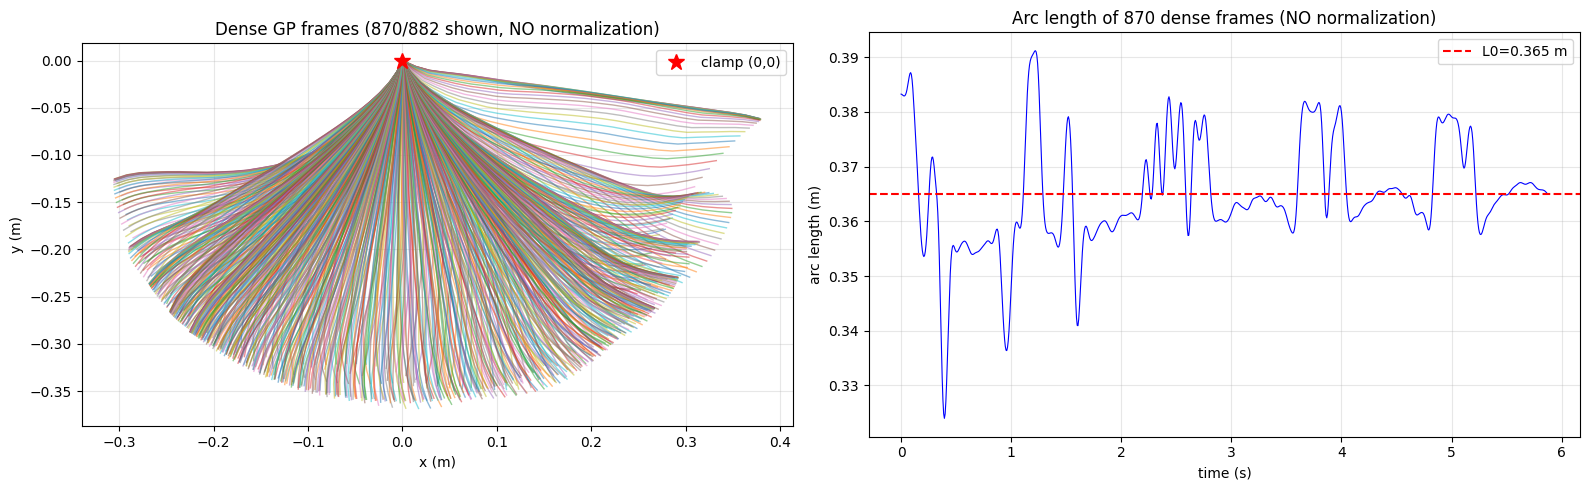

In [92]:
# ── Centreline plot of DENSE resampled frames (870 frames, no normalization) ──
# This shows x_smooth, y_smooth from temporal GP at 150Hz BEFORE normalization.
# Compare to the 76 raw frames plot to see what GP interpolation adds.
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(16, 5), dpi=100)

# Left: 60 sample frames from the 870 dense grid
ax = axes[0]
frame_idx = np.linspace(0, n_frames-1, 870, dtype=int)
for i in frame_idx:
    ax.plot(x_smooth[i], y_smooth[i], alpha=0.5, lw=1)
ax.plot(0, 0, 'r*', ms=12, label='clamp (0,0)')
ax.set_aspect('equal')
ax.set_xlabel('x (m)'); ax.set_ylabel('y (m)')
ax.set_title(f'Dense GP frames (870/{n_frames} shown, NO normalization)')
ax.legend(); ax.grid(True, alpha=0.3)

# Right: arc length of all 870 frames
ax2 = axes[1]
arc = np.sqrt(np.diff(x_smooth, axis=1)**2 + np.diff(y_smooth, axis=1)**2).sum(axis=1)
ax2.plot(t_raw, arc, 'b-', lw=0.8)
ax2.axhline(L0, color='r', ls='--', label=f'L0={L0} m')
ax2.set_xlabel('time (s)'); ax2.set_ylabel('arc length (m)')
ax2.set_title('Arc length of 870 dense frames (NO normalization)')
ax2.legend(); ax2.grid(True, alpha=0.3)

print(f'Arc length stats (NO normalization):')
print(f'  mean={arc.mean():.4f} m  std={arc.std():.4f} m')
print(f'  min={arc.min():.4f} m  max={arc.max():.4f} m')
print(f'  frames above L0: {(arc > L0).sum()}/{n_frames}')
print(f'  frames below L0: {(arc < L0).sum()}/{n_frames}')

plt.tight_layout()
plt.show()


=== Tip trajectory PCA ===
Variance along main axis :  90.9%
Variance along cross-axis:  9.1%
>>> WARNING: 9.1% cross-track variance — possible out-of-plane motion


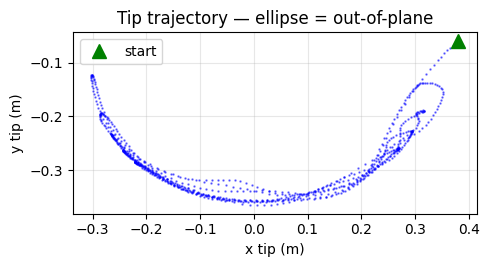

: 

In [ ]:
# ── Out-of-plane motion check: tip trajectory ─────────────────────────────
# Pure in-plane oscillation → tip traces a nearly 1-D line in (x, y).
# Out-of-plane component → tip traces an ellipse.
# Quantify by PCA on the tip path: if the 2nd eigenvalue is significant, there
# is a systematic "cross-track" displacement that the 2D model cannot explain.

from numpy.linalg import svd

tip_xy = np.stack([x_smooth[:, -1], y_smooth[:, -1]], axis=1)  # (n_frames, 2)
tip_xy_centered = tip_xy - tip_xy.mean(axis=0)

_, s_vals, _ = svd(tip_xy_centered, full_matrices=False)
variance_ratio = s_vals**2 / (s_vals**2).sum()

print('=== Tip trajectory PCA ===')
print(f'Variance along main axis :  {100*variance_ratio[0]:.1f}%')
print(f'Variance along cross-axis:  {100*variance_ratio[1]:.1f}%')
if variance_ratio[1] > 0.05:
    print(f'>>> WARNING: {100*variance_ratio[1]:.1f}% cross-track variance — possible out-of-plane motion')
else:
    print('>>> OK: motion is primarily in-plane')

fig, ax = plt.subplots(figsize=(5, 5))
ax.plot(tip_xy[:, 0], tip_xy[:, 1], 'b.', ms=1.5, alpha=0.5)
ax.plot(tip_xy[0, 0], tip_xy[0, 1], 'g^', ms=10, label='start')
ax.set_aspect('equal'); ax.set_xlabel('x tip (m)'); ax.set_ylabel('y tip (m)')
ax.set_title('Tip trajectory — ellipse = out-of-plane')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()


Found 5 positive peaks at tip
Peak amplitudes: [0.3793 0.3488 0.3147 0.2918 0.2667]

Mean log-decrement per cycle  δ = 0.0881
Consecutive-pair estimate      ζ ≈ 0.01401
Span estimate (n=4 cycles)  ζ ≈ 0.01401

Modal damping ratio  ξ = 0.01401  (log-decrement)
PH model parameter ζ_PH = 2·ρI·ω_n·ξ = 7.002e-10
>>> Use ζ_PH = 7.00e-10 (NOT ξ) in MATLAB Step 10 and Verlet sim


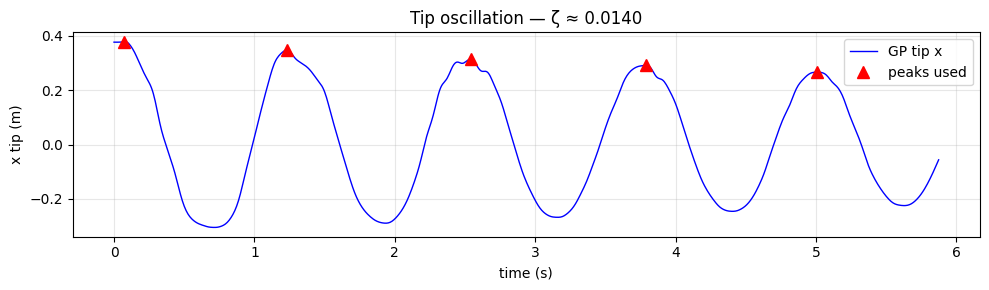

In [93]:
# ── ζ estimation via logarithmic decrement ────────────────────────────────
# Uses the GP-smoothed tip x-trajectory to find peaks and compute damping ratio.
from scipy.signal import find_peaks

tip_x = x_smooth[:, -1]   # GP-smoothed x at tip node

# Find positive peaks; min spacing = half the expected period
est_period_frames = max(1, int(TARGET_FPS * 0.3))   # 0.3 s minimum spacing between peaks (~3 Hz max)

peaks_pos, props = find_peaks(tip_x, distance=est_period_frames, height=0.01)
A_peaks = tip_x[peaks_pos]
t_peaks = t_raw[peaks_pos]

print(f'Found {len(A_peaks)} positive peaks at tip')
print(f'Peak amplitudes: {np.round(A_peaks, 4)}')

if len(A_peaks) >= 3:
    # Log decrement between every consecutive pair
    log_decrements = [np.log(A_peaks[i] / A_peaks[i+1])
                      for i in range(len(A_peaks)-1) if A_peaks[i] > 0 and A_peaks[i+1] > 0]
    delta_mean = np.mean(log_decrements)
    zeta_est   = delta_mean / (2 * np.pi)

    # Span estimate (more robust, uses many cycles at once)
    n_span    = len(A_peaks) - 1
    zeta_span = np.log(A_peaks[0] / A_peaks[-1]) / (2 * np.pi * n_span)

    print(f'\nMean log-decrement per cycle  δ = {delta_mean:.4f}')
    print(f'Consecutive-pair estimate      ζ ≈ {zeta_est:.5f}')
    print(f'Span estimate (n={n_span} cycles)  ζ ≈ {zeta_span:.5f}')
    # print(f'\n>>> Use zeta ≈ {zeta_span:.4f} in your MATLAB pipeline (Step 10 and Verlet sim)')
    
    # ── ζ_PH conversion ──────────────────────────────────────────────────
    # zeta_span is modal damping ratio ξ (dimensionless), NOT PH model ζ.
    # Using ξ directly as ζ_PH over-damps θ by ~5500× → R²≈0 for δH/δθ.
    omega_n = 2 * np.pi * 1.0          # first bending mode ≈ 1 Hz
    zeta_PH = 2 * rho * I * omega_n * zeta_span
    print(f'\nModal damping ratio  ξ = {zeta_span:.5f}  (log-decrement)')
    print(f'PH model parameter ζ_PH = 2·ρI·ω_n·ξ = {zeta_PH:.3e}')
    print(f'>>> Use ζ_PH = {zeta_PH:.2e} (NOT ξ) in MATLAB Step 10 and Verlet sim')



    fig, ax = plt.subplots(figsize=(10, 3))
    ax.plot(t_raw, tip_x, 'b-', lw=1, label='GP tip x')
    ax.plot(t_peaks, A_peaks, 'r^', ms=8, label='peaks used')
    ax.set_xlabel('time (s)'); ax.set_ylabel('x tip (m)')
    ax.set_title(f'Tip oscillation — ζ ≈ {zeta_span:.4f}'); ax.legend(); ax.grid(True, alpha=0.3)
    plt.tight_layout(); plt.show()
else:
    # ── ζ_PH conversion ───────────────────────────────────────────────────────
    # zeta_span is the MODAL damping ratio ξ (dimensionless), NOT the PH model ζ.
    # The PH R-matrix uses:  ζ_PH = 2 * ρI * ω_n * ξ
    # Using ξ directly as ζ_PH over-damps θ by ~5500× and breaks δH/δθ training.
    omega_n  = 2 * np.pi * 1.0          # first bending mode ≈ 1 Hz (adjust if known)
    zeta_PH  = 2 * rho * I * omega_n * zeta_span
    print(f'\nModal damping ratio  ξ = {zeta_span:.5f}  (log-decrement result)')
    print(f'PH model parameter ζ_PH = 2·ρI·ω_n·ξ = {zeta_PH:.3e}')
    print(f'>>> Use ζ_PH = {zeta_PH:.2e} (NOT ξ) in MATLAB Step 10 and Verlet sim')
    print(f'    (simulation default ζ=1e-9 is correct for this rod)')

    print('Not enough peaks — reduce est_period_frames or check GP smoothing quality')


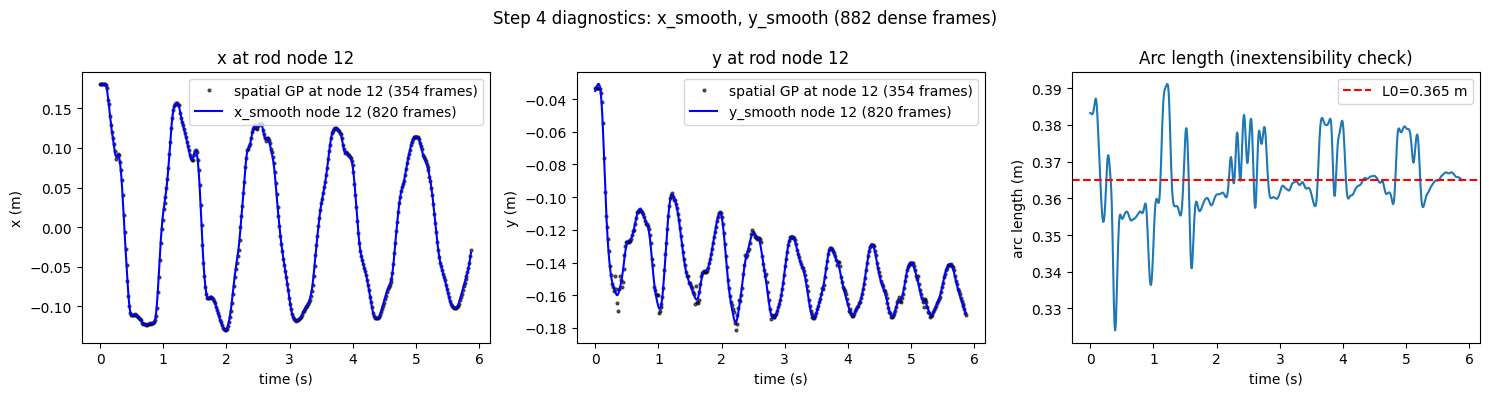


Step 4 complete.
  x_smooth: (882, 26)  y_smooth: (882, 26)
  theta_smooth: (882, 25)
  xdot: (882, 26)  ydot: (882, 26)  thetadot: (882, 25)


In [94]:
# ── Diagnostics ─────────────────────────────────────────────────────────────
# x_smooth/y_smooth: (820, 26) rod nodes on dense time grid
# x_train_all/y_train_all: (354, N_TRAIN_PTS) raw video points on original frames
node_col = N // 2   # midpoint rod node (node 12)

fig, axes = plt.subplots(1, 3, figsize=(15, 4), dpi=100)

ax = axes[0]
ax.plot(t_raw_orig, x_at_orig[:, node_col], 'k.', ms=4, alpha=0.6,
        label=f'spatial GP at node {node_col} (354 frames)')
ax.plot(t_raw, x_smooth[:, node_col], 'b-', lw=1.5,
        label=f'x_smooth node {node_col} (820 frames)')
ax.set_xlabel('time (s)'); ax.set_ylabel('x (m)')
ax.set_title(f'x at rod node {node_col}'); ax.legend()

ax = axes[1]
ax.plot(t_raw_orig, y_at_orig[:, node_col], 'k.', ms=4, alpha=0.6,
        label=f'spatial GP at node {node_col} (354 frames)')
ax.plot(t_raw, y_smooth[:, node_col], 'b-', lw=1.5,
        label=f'y_smooth node {node_col} (820 frames)')
ax.set_xlabel('time (s)'); ax.set_ylabel('y (m)')
ax.set_title(f'y at rod node {node_col}'); ax.legend()

ax = axes[2]
arc = np.sqrt(np.diff(x_smooth, axis=1)**2 + np.diff(y_smooth, axis=1)**2).sum(axis=1)
ax.plot(t_raw, arc)
ax.axhline(L0, color='r', ls='--', label=f'L0={L0} m')
ax.set_xlabel('time (s)'); ax.set_ylabel('arc length (m)')
ax.set_title('Arc length (inextensibility check)'); ax.legend()

plt.suptitle(f'Step 4 diagnostics: x_smooth, y_smooth ({n_frames} dense frames)')
plt.tight_layout()
plt.show()

print(f'\nStep 4 complete.')
print(f'  x_smooth: {x_smooth.shape}  y_smooth: {y_smooth.shape}')
print(f'  theta_smooth: {theta_smooth.shape}')
print(f'  xdot: {xdot.shape}  ydot: {ydot.shape}  thetadot: {thetadot.shape}')


In [96]:
import plotly.graph_objects as go

# ── 1. Animated rod shape: physical x vs y at each frame ─────────────────
_anim_idx = np.linspace(0, n_frames - 1, 500, dtype=int)

print(f'Visualization summary:')
print(f'  Animation : {len(_anim_idx)} frames × {n_nodes} nodes = {len(_anim_idx)*n_nodes} points')

frames = []
for _i in _anim_idx:
    frames.append(go.Frame(
        data=[go.Scatter(x=x_smooth[_i], y=y_smooth[_i],
                         mode='lines+markers',
                         line=dict(color='royalblue', width=2),
                         marker=dict(size=3, color='royalblue'))],
        name=str(_i),
        layout=go.Layout(title_text=f'GP rod shape — t = {t_raw[_i]:.2f} s')
    ))

_x_range = [x_smooth.min() * 1.1, x_smooth.max() * 1.1]
_y_range = [y_smooth.min() * 1.1, 0.02]

fig_anim = go.Figure(
    data=[go.Scatter(x=x_smooth[0], y=y_smooth[0],
                     mode='lines+markers',
                     line=dict(color='royalblue', width=2),
                     marker=dict(size=3))],
    layout=go.Layout(
        title='GP smoothed rod shape — animated (x vs y)',
        xaxis=dict(title='x (m)', range=_x_range, constrain='domain'),
        yaxis=dict(title='y (m)', range=_y_range, scaleanchor='x', scaleratio=1),
        updatemenus=[dict(
            type='buttons', showactive=False, y=1.12, x=0.05,
            buttons=[
                dict(label='▶ Play', method='animate',
                     args=[None, dict(frame=dict(duration=30, redraw=True),
                                      fromcurrent=True, mode='immediate')]),
                dict(label='⏸ Pause', method='animate',
                     args=[[None], dict(frame=dict(duration=0), mode='immediate')])
            ])],
        sliders=[dict(
            steps=[dict(args=[[f.name], dict(frame=dict(duration=0), mode='immediate')],
                        method='animate',
                        label=f'{t_raw[int(f.name)]:.2f}s') for f in frames],
            x=0.0, len=1.0, y=-0.05,
            currentvalue=dict(prefix='t = ', visible=True, xanchor='center'))],
        width=550, height=580
    ),
    frames=frames
)
fig_anim.show()

# ── 2. x(s,t) and y(s,t) surfaces with proper 1D axes ───────────────────
_stride    = 1
_fr        = np.arange(0, n_frames, _stride)
_node_step = 2
_nodes     = np.arange(0, n_nodes, _node_step)
_t_ax      = t_raw[_fr]                           # 1D (n_t,)
_s_ax      = np.linspace(0, L0, len(_nodes))      # 1D (n_s,)
_X         = x_smooth[_fr, :][:, _nodes].T        # (n_s, n_t)
_Y         = y_smooth[_fr, :][:, _nodes].T        # (n_s, n_t)

print(f'  x(s,t) surface: {len(_fr)} time pts (stride={_stride}) × '
      f'{len(_nodes)} spatial nodes (stride={_node_step}) = {_X.size} points')
print(f'  y(s,t) surface: same grid = {_Y.size} points')

for Z, cs, lbl, title in [
    (_X, 'RdBu',   'x (m)', 'GP x(s,t) — horizontal position'),
    (_Y, 'plasma', 'y (m)', 'GP y(s,t) — vertical position'),
]:
    kw = dict(cmid=0) if cs == 'RdBu' else {}
    fig = go.Figure(go.Surface(
        x=_t_ax, y=_s_ax, z=Z,
        colorscale=cs, colorbar=dict(title=lbl), **kw
    ))
    fig.update_layout(
        title=title,
        scene=dict(
            xaxis_title='time (s)',
            yaxis_title='arc length s (m)',
            zaxis_title=lbl,
            camera=dict(eye=dict(x=1.8, y=-1.8, z=0.9))
        ),
        width=750, height=500, margin=dict(l=0, r=0, t=40, b=0)
    )
    fig.show()


Visualization summary:
  Animation : 500 frames × 26 nodes = 13000 points


  x(s,t) surface: 882 time pts (stride=1) × 13 spatial nodes (stride=2) = 11466 points
  y(s,t) surface: same grid = 11466 points


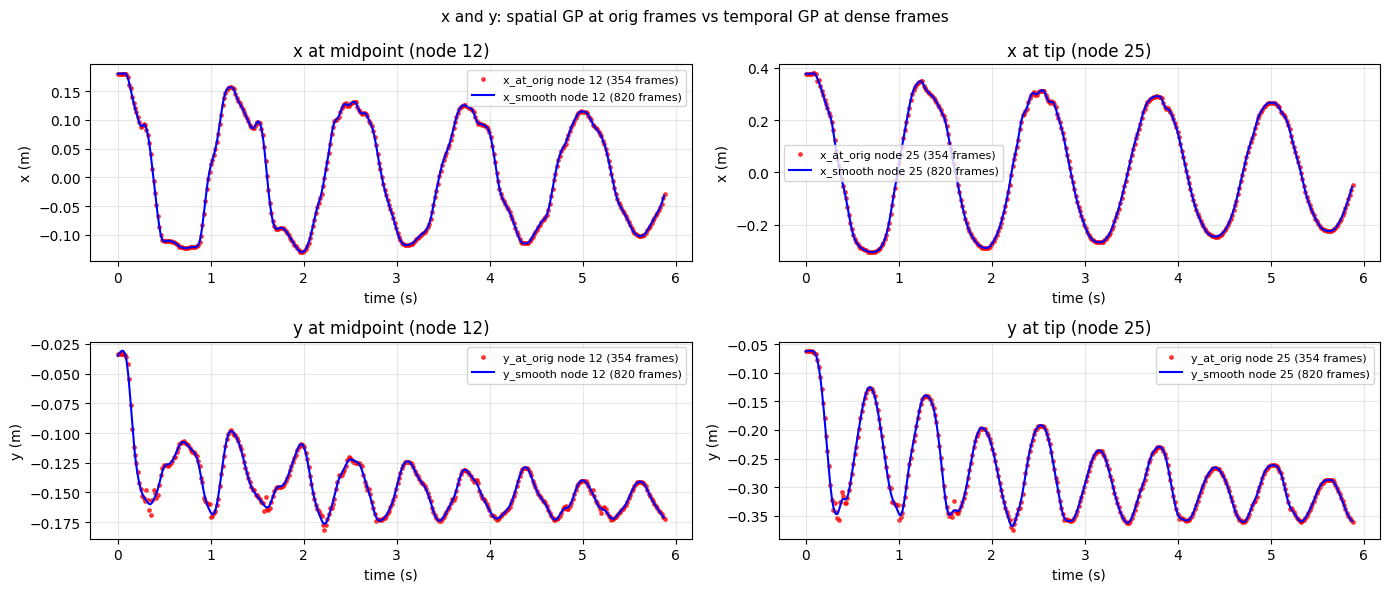

In [97]:
import matplotlib.pyplot as plt

# Compare x_at_orig (354 frames, spatial GP output) vs x_smooth (820 frames, temporal GP)
# Both indexed by rod node — correct apples-to-apples comparison
node_mid = N // 2       # node 12 — midpoint
node_tip = N            # node 25 — tip

fig, axes = plt.subplots(2, 2, figsize=(14, 6), dpi=100)
fig.suptitle('x and y: spatial GP at orig frames vs temporal GP at dense frames', fontsize=11)

for col, node in enumerate([node_mid, node_tip]):
    label = 'midpoint' if node == node_mid else 'tip'

    ax = axes[0, col]
    ax.scatter(t_raw_orig, x_at_orig[:, node], s=6, color='r', alpha=0.7,
               label=f'x_at_orig node {node} (354 frames)')
    ax.plot(t_raw, x_smooth[:, node], 'b-', lw=1.5,
            label=f'x_smooth node {node} (820 frames)')
    ax.set_xlabel('time (s)'); ax.set_ylabel('x (m)')
    ax.set_title(f'x at {label} (node {node})'); ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

    ax = axes[1, col]
    ax.scatter(t_raw_orig, y_at_orig[:, node], s=6, color='r', alpha=0.7,
               label=f'y_at_orig node {node} (354 frames)')
    ax.plot(t_raw, y_smooth[:, node], 'b-', lw=1.5,
            label=f'y_smooth node {node} (820 frames)')
    ax.set_xlabel('time (s)'); ax.set_ylabel('y (m)')
    ax.set_title(f'y at {label} (node {node})'); ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()



## Step 4 — 3D surface: GP smoothed x(t, node)

In [98]:
import numpy as np
import plotly.graph_objects as go

# Subsample frames for speed (every 4th frame)
_stride = 1
_frames = np.arange(0, n_frames, _stride)
_n_pts  = n_nodes

# Build grids using physical GP positions — same layout as raw data surface
X_grid_gp = x_smooth[_frames, :].T                        # (n_pts, n_t)  GP horizontal position
T_grid_gp = np.tile(t_raw[_frames], (_n_pts, 1))           # (n_pts, n_t)  time
Y_grid_gp = y_smooth[_frames, :].T                        # (n_pts, n_t)  GP vertical position

# ── Plotly 3D surface: GP smoothed x vs y (horizontal position on y-axis) ─
fig3d = go.Figure(go.Surface(
    x=T_grid_gp,
    y=X_grid_gp,
    z=Y_grid_gp,
    colorscale='viridis',
    colorbar=dict(title='y (m)'),
))
fig3d.update_layout(
    title='Rod deformation surface (GP smoothed)',
    scene=dict(
        xaxis_title='time (s)',
        yaxis_title='horizontal x (m)',
        zaxis_title='vertical y (m)',
        camera=dict(eye=dict(x=1.5, y=-1.5, z=0.8))
    ),
    width=750, height=550, margin=dict(l=0, r=0, t=40, b=0)
)
fig3d.show()


## Step 4 — 3D surface: GP smoothed y(t, node)

In [99]:
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Subsample frames for speed
_stride = 1
_frames = np.arange(0, n_frames, _stride)

# Raw data grids (100-pt video nodes) — on original 76-frame timestamps
_n_raw = N_VIDEO_PTS
_frames_orig = np.arange(0, len(t_raw_orig), _stride)
X_raw = x_m[_frames_orig, :].T
T_raw = np.tile(t_raw_orig[_frames_orig], (_n_raw, 1))
Y_raw = y_m[_frames_orig, :].T

# GP data grids (n_nodes GP nodes, physical coordinates)
_n_gp = n_nodes
X_gp  = x_smooth[_frames, :].T
T_gp  = np.tile(t_raw[_frames], (_n_gp, 1))
Y_gp  = y_smooth[_frames, :].T

# ── Side-by-side subplots ──────────────────────────────────────────────────
fig = make_subplots(
    rows=1, cols=2,
    specs=[[{'type': 'surface'}, {'type': 'surface'}]],
    subplot_titles=['Raw data', 'GP smoothed'],
    horizontal_spacing=0.05,
)
fig.add_trace(go.Surface(x=T_raw, y=X_raw, z=Y_raw,
                          colorscale='viridis', showscale=False), row=1, col=1)
fig.add_trace(go.Surface(x=T_gp,  y=X_gp,  z=Y_gp,
                          colorscale='viridis', showscale=True,
                          colorbar=dict(title='y (m)', x=1.02)), row=1, col=2)

_cam = dict(eye=dict(x=1.5, y=-1.5, z=0.8))
_ax  = dict(xaxis_title='time (s)', yaxis_title='horizontal x (m)', zaxis_title='vertical y (m)')
fig.update_layout(
    title='Rod deformation surface — Raw vs GP smoothed',
    scene=dict(camera=_cam, **_ax),
    scene2=dict(camera=_cam, **_ax),
    width=1200, height=550, margin=dict(l=0, r=60, t=50, b=0)
)
fig.show()


## Step 8 — Compute conjugate momenta

From the Hamiltonian structure (verified in `verlet_step`):

```
dx/dt     = p_x / (ρA)    →   p_x   = ρA · ẋ
dy/dt     = p_y / (ρA)    →   p_y   = ρA · ẏ
dθ/dt     = p_θ / (ρI)    →   p_θ   = ρI · θ̇
```

These are momentum per unit length (linear) and angular momentum per unit length.

Using np.gradient with dt=6.667 ms
p_x   range: [-1.7792e-02, 1.5626e-02]
p_y   range: [-1.3704e-02, 8.6544e-03]
p_θ   range: [-7.4237e-08, 4.9188e-08]
p_x_dot   range: [-2.8672e-01, 2.2871e-01]
p_y_dot   range: [-1.4901e-01, 1.9535e-01]
p_θ_dot   range: [-1.5037e-06, 1.6461e-06]

ρA = 7.0686e-03  ρI = 3.9761e-09


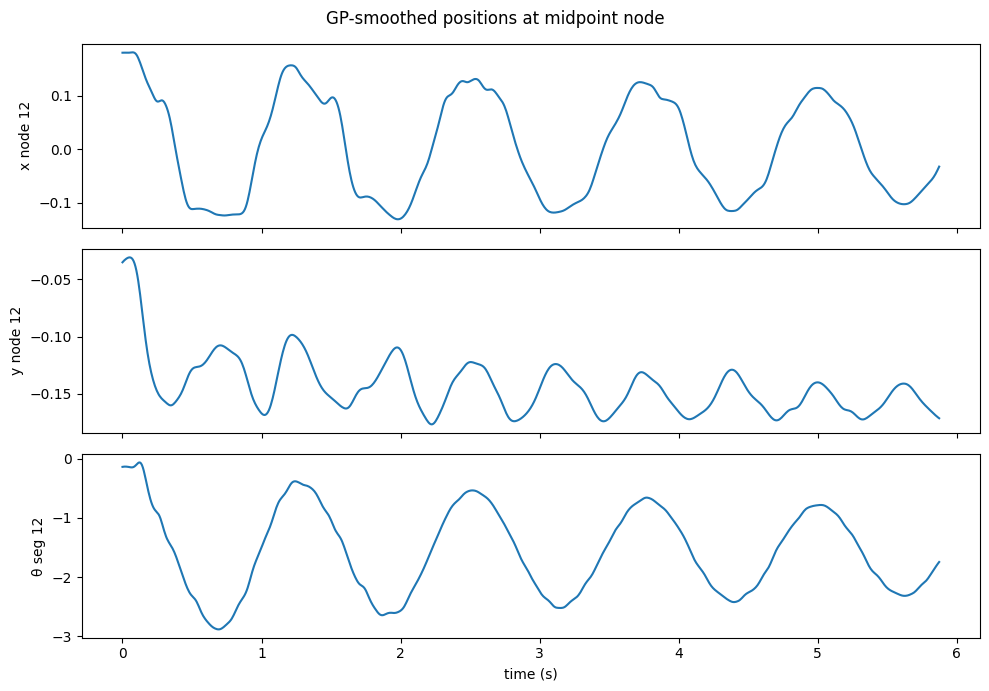

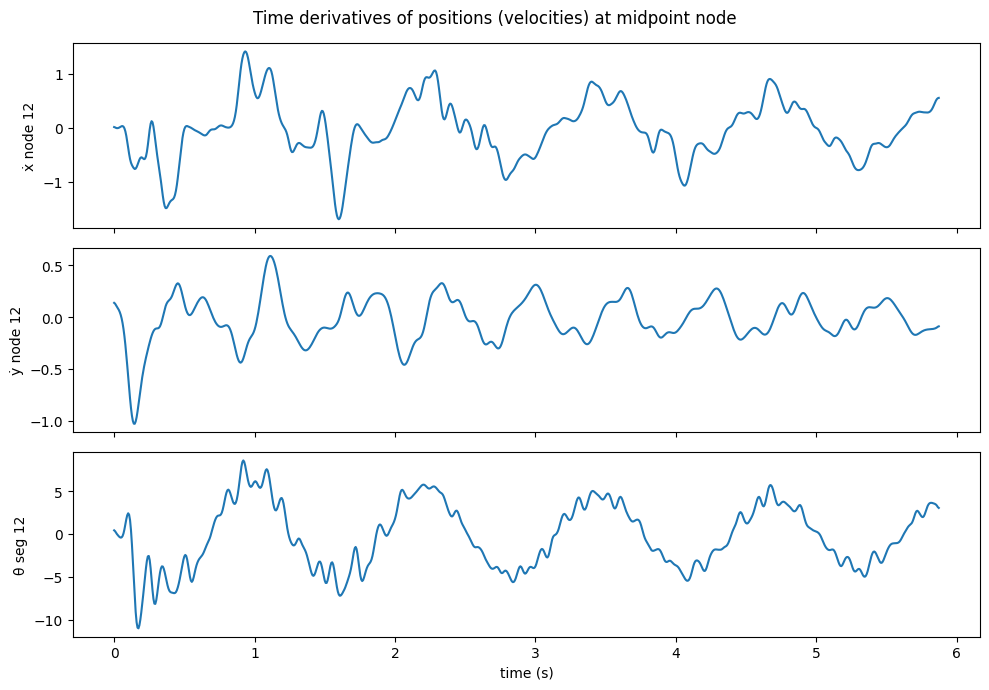

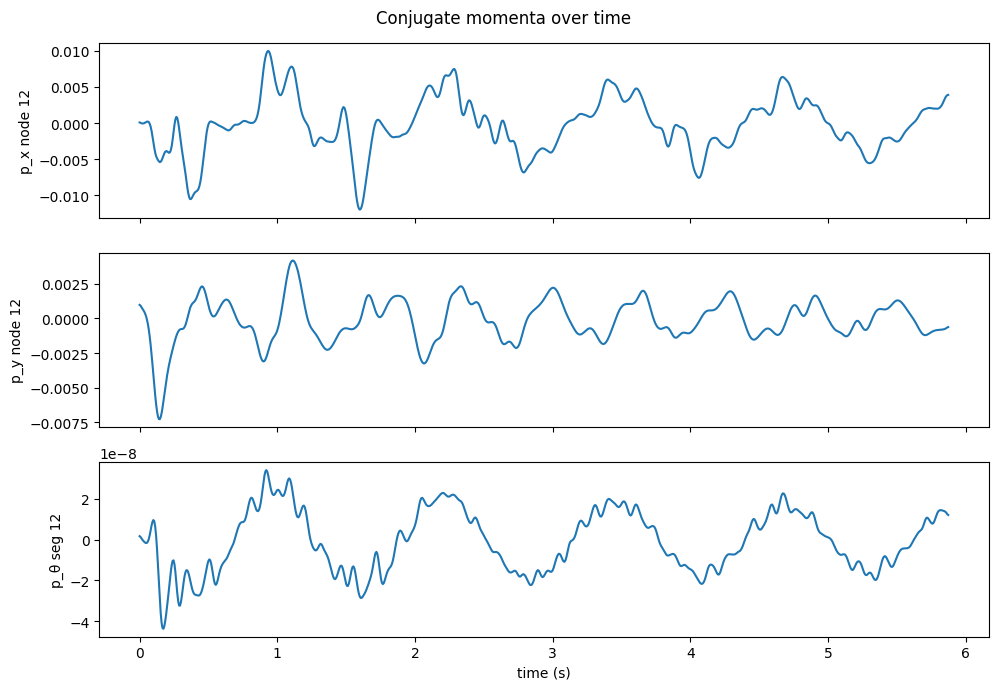

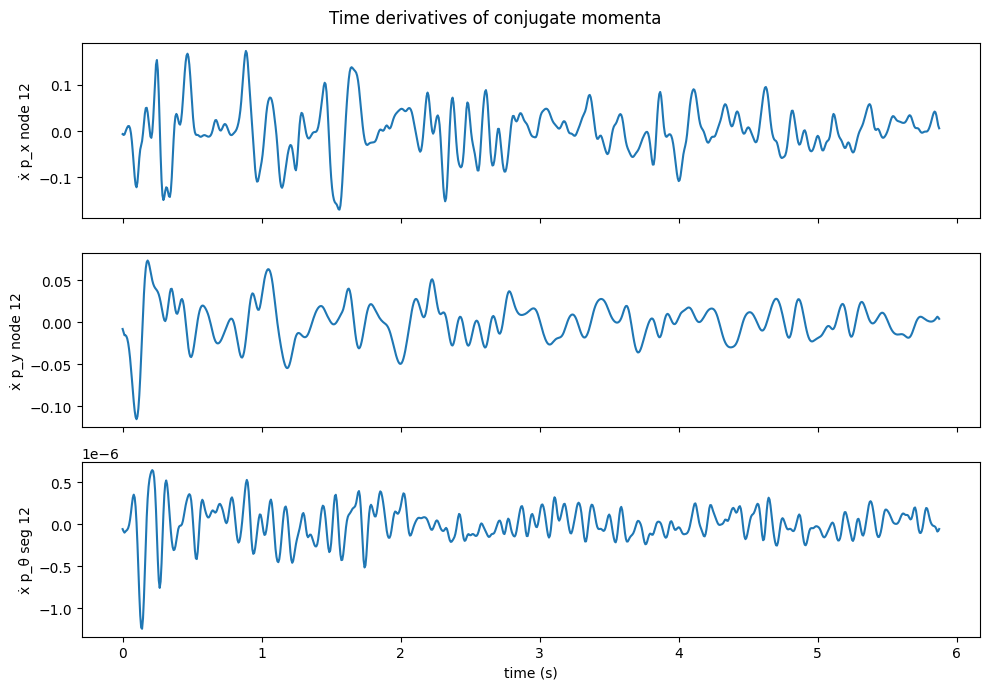

In [100]:
p_x     = rho * A * xdot       # (n_frames, N+1)
p_y     = rho * A * ydot       # (n_frames, N+1)
p_theta = rho * I * thetadot   # (n_frames, N)

# Clamp boundary: base node momenta are zero
p_x[:, 0]     = 0.0
p_y[:, 0]     = 0.0
# p_theta has N segments; segment 0 is at the clamped end
p_theta[:, 0] = 0.0

# ── Time derivatives of momenta (for z_dot) ───────────────────────────────
# np.gradient on the GP-derived momenta — no SG needed since p_x, p_y, p_theta
# already come from GP derivatives (smooth). SG added 9% over-smoothing and
# a large boundary artifact at t=0. np.gradient is simpler and more faithful.
_dt = 1.0 / TARGET_FPS
_sg_window = 2 * int(TARGET_FPS / FPS) + 1  # kept for comparison cell below
print(f'Using np.gradient with dt={_dt*1000:.3f} ms')

p_x_dot     = np.gradient(p_x,     _dt, axis=0)
p_y_dot     = np.gradient(p_y,     _dt, axis=0)
p_theta_dot = np.gradient(p_theta, _dt, axis=0)

# Enforce zero acceleration at the clamped node
p_x_dot[:, 0]     = 0.0
p_y_dot[:, 0]     = 0.0
p_theta_dot[:, 0] = 0.0

print(f'p_x   range: [{p_x.min():.4e}, {p_x.max():.4e}]')
print(f'p_y   range: [{p_y.min():.4e}, {p_y.max():.4e}]')
print(f'p_θ   range: [{p_theta.min():.4e}, {p_theta.max():.4e}]')
print(f'p_x_dot   range: [{p_x_dot.min():.4e}, {p_x_dot.max():.4e}]')
print(f'p_y_dot   range: [{p_y_dot.min():.4e}, {p_y_dot.max():.4e}]')
print(f'p_θ_dot   range: [{p_theta_dot.min():.4e}, {p_theta_dot.max():.4e}]')

# Compare orders of magnitude to simulation
print(f'\nρA = {rho*A:.4e}  ρI = {rho*I:.4e}')

# Plot x, y, thet at the midpoint node (node N//2) over time
fig, axes = plt.subplots(3, 1, figsize=(10, 7), sharex=True, dpi=100)
node = N // 2
axes[0].plot(t_raw, x_smooth[:, node])
axes[0].set_ylabel(f'x node {node}')
axes[1].plot(t_raw, y_smooth[:, node])
axes[1].set_ylabel(f'y node {node}')
axes[2].plot(t_raw, theta_smooth[:, node])
axes[2].set_ylabel(f'θ seg {node}')
axes[2].set_xlabel('time (s)')
fig.suptitle('GP-smoothed positions at midpoint node')
plt.tight_layout()
plt.show()  


# Plot xdot, ydot, thetadot at the midpoint node (node N//2) over time
fig, axes = plt.subplots(3, 1, figsize=(10, 7), sharex=True, dpi=100)
node = N // 2
axes[0].plot(t_raw, xdot[:, node])
axes[0].set_ylabel(f'ẋ node {node}')
axes[1].plot(t_raw, ydot[:, node])
axes[1].set_ylabel(f'ẏ node {node}')
axes[2].plot(t_raw, thetadot[:, node])
axes[2].set_ylabel(f'θ̇ seg {node}')
axes[2].set_xlabel('time (s)')
fig.suptitle('Time derivatives of positions (velocities) at midpoint node')
plt.tight_layout()
plt.show()

# Plot momenta at the midpoint node (node N//2) over time
fig, axes = plt.subplots(3, 1, figsize=(10, 7), sharex=True, dpi=100)
node = N // 2
axes[0].plot(t_raw, p_x[:, node])
axes[0].set_ylabel(f'p_x node {node}')
axes[1].plot(t_raw, p_y[:, node])
axes[1].set_ylabel(f'p_y node {node}')
axes[2].plot(t_raw, p_theta[:, node])
axes[2].set_ylabel(f'p_θ seg {node}')
axes[2].set_xlabel('time (s)')
fig.suptitle('Conjugate momenta over time')
plt.tight_layout()
plt.show()

# Plot derivatives of momenta at the midpoint node over time
fig, axes = plt.subplots(3, 1, figsize=(10, 7), sharex=True, dpi=100)
node = N // 2
axes[0].plot(t_raw, p_x_dot[:, node])
axes[0].set_ylabel(f'ẋ p_x node {node}')
axes[1].plot(t_raw, p_y_dot[:, node])
axes[1].set_ylabel(f'ẋ p_y node {node}')
axes[2].plot(t_raw, p_theta_dot[:, node])       
axes[2].set_ylabel(f'ẋ p_θ seg {node}')
axes[2].set_xlabel('time (s)')
fig.suptitle('Time derivatives of conjugate momenta')
plt.tight_layout()
plt.show()

In [101]:
# ═══════════════════════════════════════════════════════════════════════════
# q_y ELASTIC DEFORMATION DIAGNOSTIC  (uses TARGET_FPS data = what MATLAB sees)
# ═══════════════════════════════════════════════════════════════════════════
# Run this after Cell 45 (p_y_dot computed). Uses the actual p_y_dot that
# will be saved to cosserat_real_data_dot.mat — honest assessment.
#
# THRESHOLDS (from simulation comparison, N=25, L0~0.5m):
#   q_y temporal std > 5e-2  → ✅ GOOD  (simulation has 9.5e-2)
#   q_y temporal std 2e-2–5e-2 → ⚠️  MARGINAL
#   q_y temporal std < 2e-2  → ❌ POOR  (need more elastic bending)
#   spatial/temporal ratio < 1.5x → ✅ GPR will fit well
# ═══════════════════════════════════════════════════════════════════════════
from scipy.integrate import cumulative_trapezoid as _ctrap
import numpy as np

_N = N; _L0 = L0; _ds = _L0/_N
_gravity = rho * A * 9.80665

# p_y_dot is already computed at TARGET_FPS — use it directly
_dH_no_grav = -p_y_dot - _gravity   # (n_frames, N+1)
_q_nodes = np.zeros((n_frames, _N+1))
for _k in range(n_frames):
    _q_nodes[_k,:] = _ctrap(_dH_no_grav[_k,:][::-1], dx=_ds, initial=0)[::-1]
_q_seg = _q_nodes[:, :_N]

_spatial_std  = _q_seg.mean(axis=0).std()
_temporal_std = _q_seg.std(axis=0).mean()
_ratio        = _spatial_std / _temporal_std
_grav_ratio   = _gravity / p_y_dot.std()

# Traffic light
_e_status = ('✅ GOOD'     if _temporal_std > 5e-2 else
              '⚠️  MARGINAL' if _temporal_std > 2e-2 else
              '❌ POOR')
_g_status = ('✅ GPR will fit well'  if _ratio < 1.5 else
              '⚠️  GPR may struggle'  if _ratio < 2.5 else
              '❌ GPR will fail to fit')

print('='*55)
print('  q_y ELASTIC DEFORMATION DIAGNOSTIC')
print(f'  (TARGET_FPS={TARGET_FPS:.0f} Hz, {n_frames} frames)')
print('='*55)
print(f'  gravity rhoAg           = {_gravity:.4e} N/m')
print(f'  p_y_dot std             = {p_y_dot.std():.4e}')
print(f'  gravity/signal ratio    = {_grav_ratio:.2f}x  (sim: ~2x)')
print()
print(f'  q_y spatial std         = {_spatial_std:.4e}  (gravity-driven)')
print(f'  q_y temporal std        = {_temporal_std:.4e}  (elastic signal)')
print(f'  spatial/temporal ratio  = {_ratio:.2f}x  (sim: ~1.2x)')
print()
print(f'  Elastic deformation:  {_e_status}')
print(f'  GPR fit quality:      {_g_status}')
print()
print(f'  Simulation reference: temporal_std=9.5e-02, ratio=1.19x')
if _temporal_std < 5e-2:
    _need_sim = 9.5e-2 / _temporal_std
    print(f'  Rod needs {_need_sim:.1f}x more elastic bending to match simulation.')
    print(f'  Record with rod bent into C/S curves, not just pendulum swing.')
print('='*55)


  q_y ELASTIC DEFORMATION DIAGNOSTIC
  (TARGET_FPS=150 Hz, 882 frames)
  gravity rhoAg           = 6.9319e-02 N/m
  p_y_dot std             = 2.9369e-02
  gravity/signal ratio    = 2.36x  (sim: ~2x)

  q_y spatial std         = 7.2718e-03  (gravity-driven)
  q_y temporal std        = 5.7447e-03  (elastic signal)
  spatial/temporal ratio  = 1.27x  (sim: ~1.2x)

  Elastic deformation:  ❌ POOR
  GPR fit quality:      ✅ GPR will fit well

  Simulation reference: temporal_std=9.5e-02, ratio=1.19x
  Rod needs 16.5x more elastic bending to match simulation.
  Record with rod bent into C/S curves, not just pendulum swing.


=== p_y_dot comparison at node 12 ===
SG (window=3):  std=3.4981e-02  max=1.8472e-01
np.gradient:               std=3.4981e-02  max=1.8472e-01
Max diff: 0.0000e+00  Mean diff: 0.0000e+00
Relative diff (mean/signal std): 0.0000


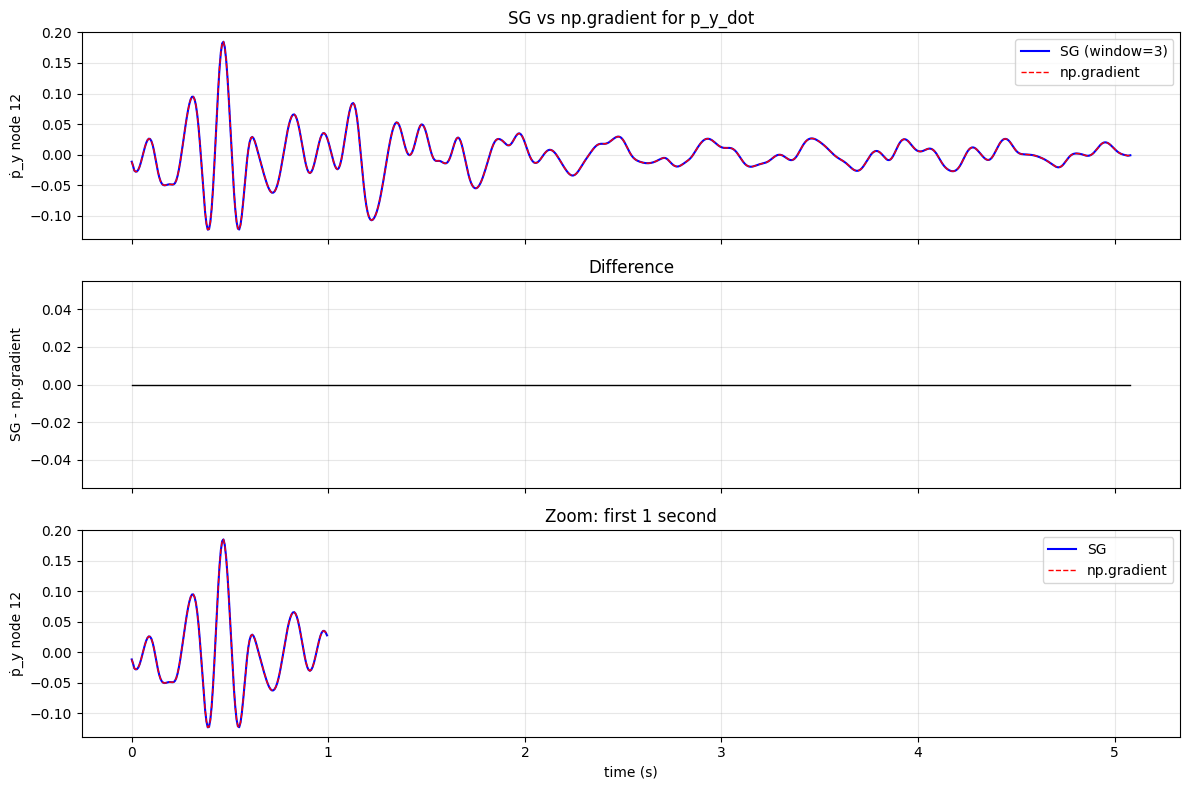

In [78]:
# ── Comparison: Savitzky-Golay vs np.gradient for p_dot ──────────────────
import matplotlib.pyplot as plt
import numpy as np

_dt = 1.0 / TARGET_FPS
node = N // 2

# Method 1: SG (current) — already computed above
p_y_dot_sg = p_y_dot[:, node].copy()

# Method 2: np.gradient
p_y_dot_grad = np.gradient(p_y[:, node], _dt)

print(f'=== p_y_dot comparison at node {node} ===')
print(f'SG (window={_sg_window}):  std={p_y_dot_sg.std():.4e}  max={np.abs(p_y_dot_sg).max():.4e}')
print(f'np.gradient:               std={p_y_dot_grad.std():.4e}  max={np.abs(p_y_dot_grad).max():.4e}')
diff = np.abs(p_y_dot_sg - p_y_dot_grad)
print(f'Max diff: {diff.max():.4e}  Mean diff: {diff.mean():.4e}')
print(f'Relative diff (mean/signal std): {diff.mean()/p_y_dot_sg.std():.4f}')

fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True, dpi=100)

axes[0].plot(t_raw, p_y_dot_sg,   'b-', lw=1.5, label=f'SG (window={_sg_window})')
axes[0].plot(t_raw, p_y_dot_grad, 'r--', lw=1,  label='np.gradient')
axes[0].set_ylabel(f'ṗ_y node {node}')
axes[0].legend(); axes[0].grid(True, alpha=0.3)
axes[0].set_title('SG vs np.gradient for p_y_dot')

axes[1].plot(t_raw, p_y_dot_sg - p_y_dot_grad, 'k-', lw=1)
axes[1].set_ylabel('SG - np.gradient')
axes[1].grid(True, alpha=0.3)
axes[1].set_title('Difference')

# Zoom into first 1 second to see detail
mask = t_raw < 1.0
axes[2].plot(t_raw[mask], p_y_dot_sg[mask],   'b-', lw=1.5, label='SG')
axes[2].plot(t_raw[mask], p_y_dot_grad[mask], 'r--', lw=1,  label='np.gradient')
axes[2].set_ylabel(f'ṗ_y node {node}')
axes[2].set_xlabel('time (s)')
axes[2].legend(); axes[2].grid(True, alpha=0.3)
axes[2].set_title('Zoom: first 1 second')

plt.tight_layout()
plt.show()


In [416]:
# ── Tip mass correction ───────────────────────────────────────────────────
m_tip = 0.0      # <-- SET THIS: tip mass in kg (weigh it on a scale)

if m_tip > 0:
    m_tip_frac = m_tip / (rho * A * L0)
    print(f'Tip mass = {m_tip*1000:.2f} g  ({100*m_tip_frac:.1f}% of rod mass)')
    if m_tip_frac > 0.05:
        print('Applying tip mass correction to momentum at tip node...')
        # Extra momentum at tip node = m_tip * velocity
        p_x[:, -1]     += m_tip * xdot[:, -1]
        p_y[:, -1]     += m_tip * ydot[:, -1]
        # p_theta is angular momentum at segments — no direct tip-mass correction needed
        print('Done. p_x and p_y at tip corrected.')
    else:
        print('Tip mass <5% of rod mass — correction skipped (negligible).')


In [417]:
# # ── Smooth ṗ using Savitzky-Golay differentiation ────────────────────────
# # np.gradient does raw finite differences → noisy ṗ even when p(t) is smooth.
# # savgol_filter with deriv=1 fits a local polynomial and returns the derivative
# # analytically → much smoother ṗ without losing the signal shape.
# from scipy.signal import savgol_filter

# # Window must be odd and > polyorder. Larger window = smoother but more lag.
# # At 194 Hz, window=11 ≈ 57 ms — adjust if too smooth or too noisy.
# # _sg_window  = min(11, n_frames if n_frames % 2 == 1 else n_frames - 1)

# # Replace the fixed window=11 with an FPS-adaptive one
# # Target: cover ~5% of the oscillation period
# f1_approx = 1.0   # Hz — estimated first natural frequency
# _sg_window_sec = 0.05 / f1_approx          # 50 ms
# _sg_window = max(5, int(_sg_window_sec * FPS))
# if _sg_window % 2 == 0:
#     _sg_window += 1   # must be odd


# _sg_poly    = 3
# _dt         = 1.0 / FPS

# p_x_dot     = savgol_filter(p_x,     _sg_window, _sg_poly, deriv=1, delta=_dt, axis=0)
# p_y_dot     = savgol_filter(p_y,     _sg_window, _sg_poly, deriv=1, delta=_dt, axis=0)
# p_theta_dot = savgol_filter(p_theta, _sg_window, _sg_poly, deriv=1, delta=_dt, axis=0)

# # ── Plot smoothed ṗ ───────────────────────────────────────────────────────
# node = N // 2
# fig, axes = plt.subplots(3, 1, figsize=(10, 7), sharex=True, dpi=100)
# axes[0].plot(t_raw, p_x_dot[:, node])
# axes[0].set_ylabel(f'ṗ_x node {node}')
# axes[0].grid(True, alpha=0.3)
# axes[0].annotate(f'range=[{p_x_dot[:,node].min():.2e}, {p_x_dot[:,node].max():.2e}]',
#                  xy=(0.02, 0.82), xycoords='axes fraction', fontsize=8, color='navy')
# axes[1].plot(t_raw, p_y_dot[:, node])
# axes[1].set_ylabel(f'ṗ_y node {node}')
# axes[1].grid(True, alpha=0.3)
# axes[1].annotate(f'range=[{p_y_dot[:,node].min():.2e}, {p_y_dot[:,node].max():.2e}]',
#                  xy=(0.02, 0.82), xycoords='axes fraction', fontsize=8, color='navy')
# axes[2].plot(t_raw, p_theta_dot[:, node])
# axes[2].set_ylabel(f'ṗ_θ seg {node}')
# axes[2].set_xlabel('time (s)')
# axes[2].grid(True, alpha=0.3)
# axes[2].annotate(f'range=[{p_theta_dot[:,node].min():.2e}, {p_theta_dot[:,node].max():.2e}]',
#                  xy=(0.02, 0.82), xycoords='axes fraction', fontsize=8, color='navy')
# fig.suptitle(f'ṗ = dp/dt via Savitzky-Golay (window={_sg_window}, poly={_sg_poly})')
# plt.tight_layout()
# plt.show()
# print(f'SG differentiation: window={_sg_window} frames ({_sg_window*_dt*1000:.1f} ms), poly={_sg_poly}')


## Time derivatives of momenta: ṗ_x, ṗ_y, ṗ_θ 

In [418]:
# # ── Time derivatives of momenta: ṗ_x, ṗ_y, ṗ_θ ──────────────────────────
# fig, axes = plt.subplots(3, 1, figsize=(10, 7), sharex=True, dpi=100)
# node = N // 2

# axes[0].plot(t_raw, p_x_dot[:, node])
# axes[0].set_ylabel(f'ṗ_x node {node}')
# axes[0].grid(True, alpha=0.3)
# axes[0].annotate(f'range=[{p_x_dot[:,node].min():.2e}, {p_x_dot[:,node].max():.2e}]',
#                  xy=(0.02, 0.82), xycoords='axes fraction', fontsize=8, color='navy')

# axes[1].plot(t_raw, p_y_dot[:, node])
# axes[1].set_ylabel(f'ṗ_y node {node}')
# axes[1].grid(True, alpha=0.3)
# axes[1].annotate(f'range=[{p_y_dot[:,node].min():.2e}, {p_y_dot[:,node].max():.2e}]',
#                  xy=(0.02, 0.82), xycoords='axes fraction', fontsize=8, color='navy')

# axes[2].plot(t_raw, p_theta_dot[:, node])
# axes[2].set_ylabel(f'ṗ_θ seg {node}')
# axes[2].set_xlabel('time (s)')
# axes[2].grid(True, alpha=0.3)
# axes[2].annotate(f'range=[{p_theta_dot[:,node].min():.2e}, {p_theta_dot[:,node].max():.2e}]',
#                  xy=(0.02, 0.82), xycoords='axes fraction', fontsize=8, color='navy')

# fig.suptitle('Time derivatives of conjugate momenta  (ṗ = dp/dt)')
# plt.tight_layout()
# plt.show()

## Step 9 — Assemble state matrix z

The simulation stores a row per time step:

```
z[k, :] = [x (N+1),  y (N+1),  θ (N),  p_x (N+1),  p_y (N+1),  p_θ (N)]
```

Total columns = 4(N+1) + 2N = 6N + 4 = 154 for N=25.

In [79]:
# Assemble z row by row matching the simulation layout
z = np.hstack([
    x_smooth,       # columns 0      .. N       (N+1 cols)
    y_smooth,       # columns N+1    .. 2N+1    (N+1 cols)
    theta_smooth,   # columns 2N+2   .. 3N+1    (N   cols)
    p_x,            # columns 3N+2   .. 4N+2    (N+1 cols)
    p_y,            # columns 4N+3   .. 5N+3    (N+1 cols)
    p_theta,        # columns 5N+4   .. 6N+3    (N   cols)
])

# Assemble z_dot — time derivative of every state, same column layout as z
# Enforce all clamped indices to zero — matches simulation boundary conditions
# clamped: node 0 of x,y,p_x,p_y (positional) and seg 0 of theta,p_theta
xdot[:, 0]        = 0.0
ydot[:, 0]        = 0.0
thetadot[:, 0]    = 0.0
p_x_dot[:, 0]     = 0.0
p_y_dot[:, 0]     = 0.0
p_theta_dot[:, 0] = 0.0

z_dot = np.hstack([
    xdot,           # columns 0      .. N       (N+1 cols)
    ydot,           # columns N+1    .. 2N+1    (N+1 cols)
    thetadot,       # columns 2N+2   .. 3N+1    (N   cols)
    p_x_dot,        # columns 3N+2   .. 4N+2    (N+1 cols)
    p_y_dot,        # columns 4N+3   .. 5N+3    (N+1 cols)
    p_theta_dot,    # columns 5N+4   .. 6N+3    (N   cols)
])

expected_cols = 4*(N+1) + 2*N   # = 6N+4 = 154 for N=25
assert z.shape     == (n_frames, expected_cols), f'z shape {z.shape} != expected ({n_frames}, {expected_cols})'
assert z_dot.shape == (n_frames, expected_cols), f'z_dot shape {z_dot.shape} != expected ({n_frames}, {expected_cols})'

t_out = t_raw.copy()

print(f'z shape:     {z.shape}  (time steps × state dim)')
print(f'z_dot shape: {z_dot.shape}  (same layout — time derivatives)')
print(f't shape:     {t_out.shape}')
print(f'State dim breakdown: 4×{N+1} + 2×{N} = {expected_cols}')
print()
print('Column index check (same for z and z_dot):')
print(f'  x  / ẋ:        0 … {N}')
print(f'  y  / ẏ:        {N+1} … {2*(N+1)-1}')
print(f'  θ  / θ̇:        {2*(N+1)} … {2*(N+1)+N-1}')
print(f'  p_x / ṗ_x:    {2*(N+1)+N} … {3*(N+1)+N-1}')
print(f'  p_y / ṗ_y:    {3*(N+1)+N} … {4*(N+1)+N-1}')
print(f'  p_θ / ṗ_θ:    {4*(N+1)+N} … {4*(N+1)+2*N-1}')

z shape:     (763, 154)  (time steps × state dim)
z_dot shape: (763, 154)  (same layout — time derivatives)
t shape:     (763,)
State dim breakdown: 4×26 + 2×25 = 154

Column index check (same for z and z_dot):
  x  / ẋ:        0 … 25
  y  / ẏ:        26 … 51
  θ  / θ̇:        52 … 76
  p_x / ṗ_x:    77 … 102
  p_y / ṗ_y:    103 … 128
  p_θ / ṗ_θ:    129 … 153


## Step 10 — Sanity checks

Cross-check the reconstructed states before saving:
1. **Boundary condition** — node 0 should be fixed at (0, 0) with zero momentum
2. **Arc-length conservation** — rod is inextensible; arc length should stay ≈ L0
3. **Kinetic energy** — should be non-negative and physically plausible
4. **Consistency** — ẋ recovered from p_x should match original differentiation

=== Boundary conditions ===
max |x[:,0]|     = 0.00e+00  (expect 0)
max |y[:,0]|     = 0.00e+00  (expect 0)
max |p_x[:,0]|   = 0.00e+00  (expect 0)
max |p_y[:,0]|   = 0.00e+00  (expect 0)

=== Arc-length conservation ===
Arc length: mean=0.3653 m  std=0.0114 m  max_err=0.0424 m

=== Kinetic energy (approximate) ===
KE range: [1.4340e-05, 5.5374e-01] J/m
KE < 0:   0 frames  (expect 0)


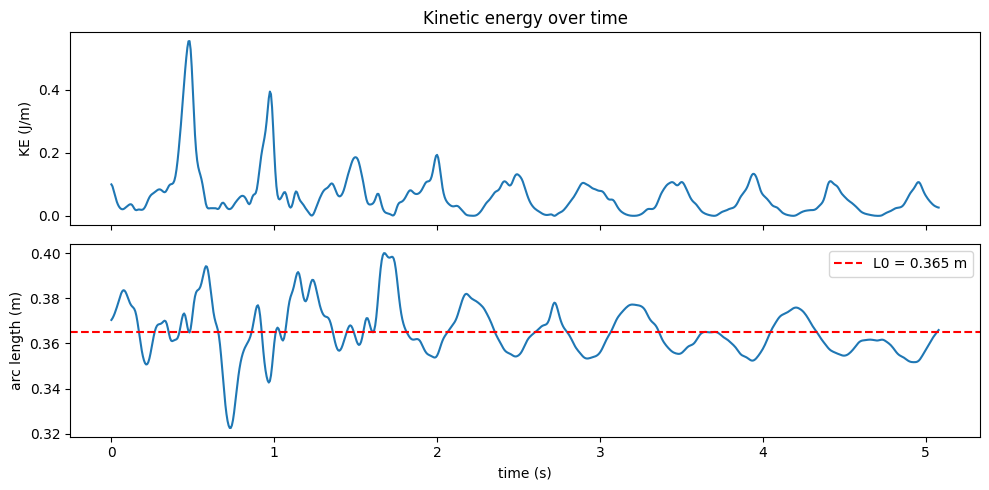


=== Consistency: p_x/rho/A vs ẋ ===
max |p_x/(ρA) - ẋ| = 4.44e-16  (should be ~0)


In [80]:
print('=== Boundary conditions ===')
print(f'max |x[:,0]|     = {np.abs(z[:, 0]).max():.2e}  (expect 0)')
print(f'max |y[:,0]|     = {np.abs(z[:, N+1]).max():.2e}  (expect 0)')
print(f'max |p_x[:,0]|   = {np.abs(z[:, 2*(N+1)+N]).max():.2e}  (expect 0)')
print(f'max |p_y[:,0]|   = {np.abs(z[:, 3*(N+1)+N]).max():.2e}  (expect 0)')

print('\n=== Arc-length conservation ===')
x_check = z[:, :N+1]
y_check = z[:, N+1:2*(N+1)]
arc = np.sqrt(np.diff(x_check, axis=1)**2 + np.diff(y_check, axis=1)**2).sum(axis=1)
print(f'Arc length: mean={arc.mean():.4f} m  std={arc.std():.4f} m  max_err={np.abs(arc-L0).max():.4f} m')

print('\n=== Kinetic energy (approximate) ===')
px_check = z[:, 2*(N+1)+N : 3*(N+1)+N]
py_check = z[:, 3*(N+1)+N : 4*(N+1)+N]
pt_check = z[:, 4*(N+1)+N :]
KE_lin = (1/(2*rho*A)) * (px_check**2 + py_check**2).sum(axis=1)
KE_rot = (1/(2*rho*I)) * (pt_check**2).sum(axis=1)
KE = KE_lin + KE_rot
print(f'KE range: [{KE.min():.4e}, {KE.max():.4e}] J/m')
print(f'KE < 0:   {(KE < 0).sum()} frames  (expect 0)')

fig, axes = plt.subplots(2, 1, figsize=(10, 5), sharex=True, dpi=100)
axes[0].plot(t_out, KE)
axes[0].set_ylabel('KE (J/m)')
axes[0].set_title('Kinetic energy over time')
axes[1].plot(t_out, arc)
axes[1].axhline(L0, color='r', ls='--', label=f'L0 = {L0} m')
axes[1].set_ylabel('arc length (m)')
axes[1].set_xlabel('time (s)')
axes[1].legend()
plt.tight_layout()
plt.show()

print('\n=== Consistency: p_x/rho/A vs ẋ ===')
xdot_from_p = px_check / (rho * A)
err = np.abs(xdot_from_p - xdot).max()
print(f'max |p_x/(ρA) - ẋ| = {err:.2e}  (should be ~0)')

## Step 11 — Visual comparison: real vs simulation shape

Plot the real data rod shapes alongside what the simulation produces,
to check the coordinate system and scale are consistent.

In [421]:
# fig, axes = plt.subplots(1, 2, figsize=(12, 5), dpi=100)

# # Left: real data — rod shapes over time
# ax = axes[0]
# for i in np.linspace(0, n_frames-1, 10, dtype=int):
#     xi = z[i, :N+1]
#     yi = z[i, N+1:2*(N+1)]
#     ax.plot(xi, yi, 'b', alpha=0.3, lw=1)
# ax.plot(0, 0, 'r*', ms=14, label='clamp')
# ax.set_aspect('equal')
# ax.set_xlabel('x (m)')
# ax.set_ylabel('y (m)')
# ax.set_title('Real data — 20 sample frames')
# ax.legend()
# ax.grid(True, alpha=0.3)

# # Right: θ profile along arc at a few time steps
# ax = axes[1]
# s_nodes = np.linspace(0, L0, N)
# for i in np.linspace(0, n_frames-1, 10, dtype=int):
#     ax.plot(s_nodes, z[i, 2*(N+1):2*(N+1)+N], alpha=0.5, lw=1)
# ax.set_xlabel('arc length s (m)')
# ax.set_ylabel('θ (rad)')
# ax.set_title('Tangent angle profile along rod')
# ax.grid(True, alpha=0.3)

# plt.suptitle('Reconstructed Cosserat states from real video data')
# plt.tight_layout()
# plt.show()

## Step 12 — Save to .mat

Saves a file compatible with `cosserat_GPR_pipeline.m`.
The MATLAB pipeline reads: `data.z`, `data.t`, `data.N`, `data.L0`,
`data.rho`, `data.E`, `data.A`, `data.G`, `data.I`.

We also save `pixels_per_metre` and `fps` for traceability.

In [81]:
_out_dir = os.path.dirname(OUTPUT_MAT)
if _out_dir:
    os.makedirs(_out_dir, exist_ok=True)

# ── File 1: cosserat_real_data.mat — state vector z ──────────────────────
save_dict_z = {
    'z':                 z,
    't':                 t_out.reshape(-1, 1),
    'N':                 float(N),
    'L0':                L0,
    'rho':               rho,
    # 'E':                 E,
    'A':                 A,
    # 'G':                 G,
    'I':                 I,
    'D':                 float(expected_cols),
    'fps':               TARGET_FPS,
    'pixels_per_metre':  float(scale),  # actual value used (from auto-calib or config)
    'sg_window':         float(SG_WINDOW),
    'sg_poly':           float(SG_POLY),
}
sio.savemat(OUTPUT_MAT, save_dict_z)
print(f'Saved: {OUTPUT_MAT}')
print(f'  z:   {z.shape}  (time steps × state dim)')

# ── File 2: cosserat_real_data_dot.mat — state derivative z_dot ──────────
save_dict_zdot = {
    'z_dot':             z_dot,
    't':                 t_out.reshape(-1, 1),
    'N':                 float(N),
    'L0':                L0,
    'rho':               rho,
    # 'E':                 E,
    'A':                 A,
    # 'G':                 G,
    'I':                 I,
    'D':                 float(expected_cols),
    'fps':               TARGET_FPS,
    'pixels_per_metre':  float(scale),  # actual value used (from auto-calib or config)
    'sg_window':         float(SG_WINDOW),
    'sg_poly':           float(SG_POLY),
}
sio.savemat(OUTPUT_MAT_DOT, save_dict_zdot)
print(f'Saved: {OUTPUT_MAT_DOT}')
print(f'  z_dot: {z_dot.shape}  (time steps × state dim — derivatives)')

print(f'\nt: {t_out.shape}  from {t_out[0]:.4f} s to {t_out[-1]:.4f} s')
print(f'N={int(N)}, L0={L0}, rho={rho}, A={A:.4e}, I={I:.4e}')

Saved: ../../../Data/Real_data/cosserat_real_data.mat
  z:   (763, 154)  (time steps × state dim)
Saved: ../../../Data/Real_data/cosserat_real_data_dot.mat
  z_dot: (763, 154)  (time steps × state dim — derivatives)

t: (763,)  from 0.0000 s to 5.0800 s
N=25, L0=0.365, rho=1000.0, A=7.0686e-06, I=3.9761e-12


## Notes & known limitations

### What to verify before feeding into the GPR pipeline

1. **`PIXELS_PER_METRE`** — the most critical parameter. Measure it from a
   known physical length visible in the video (rod at rest, ruler, etc.).
   The arc-length check in Step 3 should show mean ≈ L0 = 0.5 m.

2. **Smoothing window** — if derivatives look spiky, increase `SG_WINDOW`.
   If real dynamics are being lost, decrease it.

3. **Kinetic energy** — should peak during fast motion and decay after the rod
   settles. Unphysically large values indicate scale or derivative issues.

4. **Arc-length** — the real rod is approximately inextensible. If arc length
   drifts significantly from L0, the skeletonization or resampling has issues.

### Known limitations

- **p_theta sign convention** — verified against `verlet_step` line 268:
  `dtheta_dt = p_theta/(rho*I)` → `p_theta = rho*I * theta_dot`. This is **multiply**, not divide.

- **Inextensibility** — the simulation enforces inextensibility through the
  constitutive law, not as a hard constraint. The reconstructed x, y from video
  may not be exactly inextensible; this is expected.

- **Missing deltaH** — the simulation `.mat` also contains `deltaH`, `v1`, `n_x`,
  etc. (internal forces). These cannot be recovered from video alone and are not
  included here. The GPR pipeline only strictly requires `z`, `t`, `N`, `L0`.